# CSV Editor Notebook

> **All outputs are organised under a single project folder.**  
> Set `PROJECT_NAME` in **Cell 2 — Configuration** before running anything else.  
> Every CSV, chart and comparison file lands in:  
> `data/processed/<PROJECT_NAME>/csv/` and `data/processed/<PROJECT_NAME>/charts/`

| Cell | Operation |
|------|-----------|
| **1** | Install & Imports |
| **2** | ⚙ **Configuration — set `PROJECT_NAME` here** |
| **3** | All helper functions (run once) |
| **4** | ▶ Step 1 — Add `filename` column to source CSV |
| **5a** | ▶ Step 2a — Generate CSV from **local** image directory |
| **5b** | ▶ Step 2b — Generate CSV from **Wasabi bucket** (S3) |
| **6** | ▶ Step 3 — Compare both CSVs (stats + lists + charts) |
| **A** | Appendix — Re-run comparison from saved CSVs |
| **7** | ▶ Dataset Analysis — config (Train / Val CSVs) |
| **8** | ▶ Dataset Analysis — run (stats + charts) |

## 1 — Install & Imports

In [31]:
%pip install pandas matplotlib seaborn tqdm boto3 python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.


In [32]:
import os
import warnings
from pathlib import Path

import boto3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from botocore.config import Config
from botocore.exceptions import ClientError
from tqdm import tqdm

try:
    from dotenv import load_dotenv
    load_dotenv(Path("..") / ".env", override=True)
    print("✓ .env loaded")
except Exception:
    pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 30)

print(f"pandas  {pd.__version__}")
print("✓ imports ready")

✓ .env loaded
pandas  3.0.2
✓ imports ready


## 2 — Configuration

In [33]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PROJECT — set this before running any other cell                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
PROJECT_NAME = "GAID-v9"   # ← change to your project name

# ── Root processed directory ───────────────────────────────────────────────
PROCESSED_ROOT = Path("/home/taiaburrahman/dataset_manager_pro/data/processed")

# ── Project sub-directories (auto-derived — do not edit) ──────────────────
PROJECT_DIR = PROCESSED_ROOT / PROJECT_NAME
CSV_DIR     = PROJECT_DIR / "csv"
CHARTS_DIR  = PROJECT_DIR / "charts"

for _d in [CSV_DIR, CHARTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Alias kept for backward-compat (helper functions still use OUTPUT_DIR)
OUTPUT_DIR = CSV_DIR

# ── Source CSVs ────────────────────────────────────────────────────────────
SOURCE_CSV = "/home/taiaburrahman/dataset_manager_pro/data/csv/GAID_Dataset_v9_full_Train.csv"
VAL_CSV    = "/home/taiaburrahman/dataset_manager_pro/data/csv/GAID_Dataset_v9_full_Val.csv"

# ── Local image directory to scan (Step 2a) ────────────────────────────────
# Extracted dataset from Wasabi zip files — change if your extraction path differs
IMAGE_SCAN_DIR = "/home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset"

# ── Wasabi config (Step 2b) ────────────────────────────────────────────────
# Reads from .env automatically; override here if needed.
WASABI_ACCESS_KEY_ID     = os.getenv("WASABI_ACCESS_KEY_ID",     "")
WASABI_SECRET_ACCESS_KEY = os.getenv("WASABI_SECRET_ACCESS_KEY", "")
WASABI_BUCKET            = os.getenv("WASABI_BUCKET",            "")
WASABI_REGION            = os.getenv("WASABI_REGION",            "us-east-1")
WASABI_ENDPOINT          = os.getenv("WASABI_ENDPOINT",          "https://s3.wasabisys.com")

# S3 prefix to scan in the bucket (Step 2b)
WASABI_SCAN_PREFIX = "datasets/gen_ai_detector_dataset/"

# ── Label mapping ──────────────────────────────────────────────────────────
# key-path / folder-name substring → integer label  (0 = fake, 1 = real)
LABEL_MAP = {
    "genai":                 0,
    "ai_image_x_collection": 0,
    "human":                 1,
}

# ── File extensions to include when scanning locally ───────────────────────
# Only image formats — archives are not included since we scan extracted data
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}

# ── Summary ────────────────────────────────────────────────────────────────
print(f"┌─ Project ────────────────────────────────────────────────────────┐")
print(f"│  Name      : {PROJECT_NAME:<51}│")
print(f"│  Root      : {str(PROJECT_DIR):<51}│")
print(f"│  CSV dir   : {str(CSV_DIR):<51}│")
print(f"│  Charts    : {str(CHARTS_DIR):<51}│")
print(f"├─ Inputs ─────────────────────────────────────────────────────────┤")
print(f"│  Source CSV: {SOURCE_CSV[-51:]:<51}│")
print(f"│  Wasabi    : {WASABI_BUCKET}/{WASABI_SCAN_PREFIX}"[:67] + "│")
print(f"└──────────────────────────────────────────────────────────────────┘")

┌─ Project ────────────────────────────────────────────────────────┐
│  Name      : GAID-v9                                            │
│  Root      : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9│
│  CSV dir   : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/csv│
│  Charts    : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts│
├─ Inputs ─────────────────────────────────────────────────────────┤
│  Source CSV: manager_pro/data/csv/GAID_Dataset_v9_full_Train.csv│
│  Wasabi    : bbvision/datasets/gen_ai_detector_dataset/│
└──────────────────────────────────────────────────────────────────┘


## 3 — Helper Functions

In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _proj() -> str:
    """Return the current PROJECT_NAME global (safe default if not set)."""
    return globals().get("PROJECT_NAME", "default_project")

def _csv_dir() -> Path:
    return globals().get("CSV_DIR", Path("./processed/csv"))

def _charts_dir() -> Path:
    return globals().get("CHARTS_DIR", Path("./processed/charts"))

def _box(lines: list[str], width: int = 72) -> str:
    sep = "─" * (width - 2)
    def row(s): return f"║  {s:<{width-4}}║"
    out = [f"╔{sep}╗"]
    for l in lines:
        out.append(f"╠{sep}╣" if l == "---" else row(l))
    out.append(f"╚{sep}╝")
    return "\n".join(out)

def _pfx(p: str) -> str:
    """Convert a step prefix like '01' → '01.' (empty string → no prefix)."""
    return f"{p}." if p else ""

def _infer_label(top_folder: str) -> int | None:
    """Map a top-level subfolder name to a label using LABEL_MAP prefixes."""
    key = top_folder.lower()
    for lmap_prefix, label in LABEL_MAP.items():
        if key.startswith(lmap_prefix):
            return label
    return None


def _rel_name(path_str: str) -> str:
    """Return 'parent_folder/filename' from a full path for robust matching."""
    p = Path(str(path_str))
    return f"{p.parent.name}/{p.name}"


# ── Step 1 ─────────────────────────────────────────────────────────────────

def add_filename_column(
    source_csv:  str | Path,
    output_dir:  str | Path | None = None,
    path_col:    str = "image_path",
    output_name: str | None = None,
    prefix:      str = "01",
) -> pd.DataFrame:
    """
    Load *source_csv*, extract 'parent_folder/basename' from *path_col*,
    add it as 'filename', and save to *output_dir* (defaults to project CSV_DIR).
    *prefix* is prepended to the output filename, e.g. '01.name.csv'.
    """
    src = Path(source_csv)
    out = Path(output_dir) if output_dir else _csv_dir()
    out.mkdir(parents=True, exist_ok=True)

    print(f"Loading {src.name} …")
    df = pd.read_csv(src, dtype=str, low_memory=False)

    if path_col not in df.columns:
        raise ValueError(f"Column '{path_col}' not found. Available: {list(df.columns)}")

    df["filename"] = df[path_col].apply(_rel_name)

    stem = output_name or (src.stem + "_with_filename")
    dest = out / (_pfx(prefix) + stem + ".csv")
    df.to_csv(dest, index=False)

    print(df[[path_col, "filename"]].head(5).to_string(index=False))
    print(_box([
        f"STEP 1 — ADD FILENAME COLUMN  [project: {_proj()}]", "---",
        f"Source          : {src.name}",
        f"Saved to        : {dest}",
        "---",
        f"Rows            : {len(df):,}",
        f"Columns         : {list(df.columns)}",
        f"Unique filenames : {df['filename'].nunique():,}",
    ]))
    return df


# ── Step 2 ─────────────────────────────────────────────────────────────────

def scan_image_dir(
    scan_dir:    str | Path,
    output_dir:  str | Path | None = None,
    output_name: str = "scanned_images",
    prefix:      str = "02",
) -> pd.DataFrame:
    """
    Walk *scan_dir* recursively, collect image files, build a DataFrame
    with columns (image_path, labels, directory, filename), and save to
    *output_dir* (defaults to project CSV_DIR).
    Labels are inferred from the top-level subfolder name using LABEL_MAP.
    *prefix* is prepended to the output filename, e.g. '02.name.csv'.
    """
    root = Path(scan_dir)
    out  = Path(output_dir) if output_dir else _csv_dir()
    out.mkdir(parents=True, exist_ok=True)

    print(f"Scanning {root} …")
    records = []

    top_folders = sorted([d for d in root.iterdir() if d.is_dir()])
    print(f"  Sub-folders : {[d.name for d in top_folders]}\n")

    for top in top_folders:
        label = _infer_label(top.name)
        files = [f for f in top.rglob("*")
                 if f.is_file() and f.suffix.lower() in IMAGE_EXTS]
        for f in tqdm(files, desc=f"  {top.name}", leave=True):
            records.append({
                "image_path": str(f),
                "labels":     label,
                "directory":  top.name,
                "filename":   f"{f.parent.name}/{f.name}",
            })

    df   = pd.DataFrame(records)
    dest = out / (_pfx(prefix) + output_name + ".csv")
    df.to_csv(dest, index=False)

    label_counts = df["labels"].value_counts().to_dict()
    print(_box([
        f"STEP 2a — SCAN LOCAL DIR  [project: {_proj()}]", "---",
        f"Scanned         : {root}",
        f"Saved to        : {dest}",
        "---",
        f"Total images    : {len(df):,}",
        f"Label 0 (fake)  : {label_counts.get(0, 0):,}",
        f"Label 1 (real)  : {label_counts.get(1, 0):,}",
        f"Unknown label   : {label_counts.get(None, 0):,}",
        f"Unique filenames : {df['filename'].nunique():,}",
    ]))
    return df


# ── Step 3 ─────────────────────────────────────────────────────────────────

def compare_csvs(
    df_source:   pd.DataFrame | str | Path,
    df_scanned:  pd.DataFrame | str | Path,
    output_dir:  str | Path | None = None,
    charts_dir:  str | Path | None = None,
    compare_col: str = "filename",
    prefix:      str = "03",
) -> dict:
    """
    Compare two DataFrames (or CSV paths) on *compare_col*.

    Returns a dict with:
      common          — filenames in both
      only_in_source  — filenames only in source CSV
      only_in_scanned — filenames only in scanned CSV

    Saves difference lists to CSVs and displays bar + pie charts.
    """
    out   = Path(output_dir)  if output_dir  else _csv_dir()
    c_dir = Path(charts_dir) if charts_dir  else _charts_dir()
    out.mkdir(parents=True, exist_ok=True)
    c_dir.mkdir(parents=True, exist_ok=True)

    if isinstance(df_source, (str, Path)):
        print(f"Loading source  CSV …")
        df_source  = pd.read_csv(df_source,  dtype=str, low_memory=False)
    if isinstance(df_scanned, (str, Path)):
        print(f"Loading scanned CSV …")
        df_scanned = pd.read_csv(df_scanned, dtype=str, low_memory=False)

    if compare_col not in df_source.columns:
        df_source  = df_source.copy()
        df_source[compare_col]  = df_source["image_path"].apply(_rel_name)
    if compare_col not in df_scanned.columns:
        df_scanned = df_scanned.copy()
        df_scanned[compare_col] = df_scanned["image_path"].apply(_rel_name)

    set_src = set(df_source[compare_col].dropna())
    set_scn = set(df_scanned[compare_col].dropna())

    common          = set_src & set_scn
    only_in_source  = set_src - set_scn
    only_in_scanned = set_scn - set_src

    # ── Save difference lists ──────────────────────────────────────────────
    fp = _pfx(prefix)
    def _save_list(names, tag):
        rows = df_source[df_source[compare_col].isin(names)] if "source" in tag \
               else df_scanned[df_scanned[compare_col].isin(names)]
        p = out / f"{fp}compare_{tag}.csv"
        rows.to_csv(p, index=False)
        return p

    p_common  = out / f"{fp}compare_common.csv"
    df_source[df_source[compare_col].isin(common)].to_csv(p_common, index=False)
    p_only_src = _save_list(only_in_source,  "only_in_source")
    p_only_scn = _save_list(only_in_scanned, "only_in_scanned")

    # ── Text summary ──────────────────────────────────────────────────────
    print(_box([
        f"STEP 3 — CSV COMPARISON  [project: {_proj()}]", "---",
        f"Compare column       : '{compare_col}'",
        "---",
        f"Source CSV           : {len(set_src):>10,} unique filenames",
        f"Scanned CSV          : {len(set_scn):>10,} unique filenames",
        "---",
        f"✓  Common (both)     : {len(common):>10,}",
        f"◀  Only in source    : {len(only_in_source):>10,}",
        f"▶  Only in scanned   : {len(only_in_scanned):>10,}",
        "---",
        f"CSV dir              : {out}",
        f"Charts dir           : {c_dir}",
        f"common CSV           : {p_common.name}",
        f"only_in_source CSV   : {p_only_src.name}",
        f"only_in_scanned CSV  : {p_only_scn.name}",
    ]))

    # ── Sample lists ──────────────────────────────────────────────────────
    print("\n── Sample: common files (first 10) ──")
    display(df_source[df_source[compare_col].isin(common)][[compare_col, "labels"]].head(10))

    print("\n── Sample: only in SOURCE csv (first 10) ──")
    display(df_source[df_source[compare_col].isin(only_in_source)][[compare_col, "labels"]].head(10))

    print("\n── Sample: only in SCANNED csv (first 10) ──")
    display(df_scanned[df_scanned[compare_col].isin(only_in_scanned)][[compare_col, "labels"]].head(10))

    # ── Charts ────────────────────────────────────────────────────────────
    _plot_comparison(
        len(common), len(only_in_source), len(only_in_scanned),
        len(set_src), len(set_scn),
        df_source, df_scanned, compare_col, common, c_dir,
        prefix=prefix,
    )

    return {
        "common":          common,
        "only_in_source":  only_in_source,
        "only_in_scanned": only_in_scanned,
    }


def _plot_comparison(
    n_common, n_only_src, n_only_scn,
    n_src_total, n_scn_total,
    df_source, df_scanned, compare_col,
    common_set, out_dir,
    prefix: str = "03",
):
    """Render and save 4 charts: bar overview, stacked bar per CSV,
       two donut pies (composition of each CSV)."""
    sns.set_theme(style="whitegrid", palette="muted")
    COLORS = {"common": "#4CAF50", "only_src": "#2196F3", "only_scn": "#FF9800"}

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle("CSV Comparison — Filename Overlap Analysis",
                 fontsize=15, fontweight="bold", y=1.01)

    # ── 1. Overview bar chart ─────────────────────────────────────────────
    ax = axes[0, 0]
    categories = ["Common\n(both)", "Only in\nSource CSV", "Only in\nScanned CSV"]
    counts     = [n_common, n_only_src, n_only_scn]
    colors     = [COLORS["common"], COLORS["only_src"], COLORS["only_scn"]]
    bars = ax.bar(categories, counts, color=colors, edgecolor="white", width=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.01,
                f"{count:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title("Overview: Filename Overlap", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Files")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # ── 2. Stacked bar per CSV ────────────────────────────────────────────
    ax = axes[0, 1]
    csv_names  = ["Source CSV", "Scanned CSV"]
    n_common_s = [n_common,   n_common]
    n_unique_s = [n_only_src, n_only_scn]
    b1 = ax.bar(csv_names, n_common_s, color=COLORS["common"],  label="Common",        edgecolor="white")
    b2 = ax.bar(csv_names, n_unique_s, bottom=n_common_s,
                color=[COLORS["only_src"], COLORS["only_scn"]], label="Unique to this", edgecolor="white")
    for bar, total in zip(b1, [n_src_total, n_scn_total]):
        ax.text(bar.get_x() + bar.get_width()/2, total + max(n_src_total, n_scn_total) * 0.01,
                f"Total\n{total:,}", ha="center", va="bottom", fontsize=9)
    ax.set_title("Per-CSV Composition", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Files")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()

    # ── 3. Source CSV donut ───────────────────────────────────────────────
    ax = axes[1, 0]
    wedge_sizes = [n_common, n_only_src]
    wedge_labels = [f"Common\n{n_common:,}", f"Only in Source\n{n_only_src:,}"]
    wedge_colors = [COLORS["common"], COLORS["only_src"]]
    if sum(wedge_sizes) > 0:
        wedges, texts, autotexts = ax.pie(
            wedge_sizes, labels=wedge_labels, colors=wedge_colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(width=0.55, edgecolor="white"),
        )
        for t in autotexts: t.set_fontsize(9)
    ax.set_title(f"Source CSV  ({n_src_total:,} total)", fontsize=12, fontweight="bold")

    # ── 4. Scanned CSV donut ──────────────────────────────────────────────
    ax = axes[1, 1]
    wedge_sizes = [n_common, n_only_scn]
    wedge_labels = [f"Common\n{n_common:,}", f"Only in Scanned\n{n_only_scn:,}"]
    wedge_colors = [COLORS["common"], COLORS["only_scn"]]
    if sum(wedge_sizes) > 0:
        wedges, texts, autotexts = ax.pie(
            wedge_sizes, labels=wedge_labels, colors=wedge_colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(width=0.55, edgecolor="white"),
        )
        for t in autotexts: t.set_fontsize(9)
    ax.set_title(f"Scanned CSV  ({n_scn_total:,} total)", fontsize=12, fontweight="bold")

    plt.tight_layout()
    chart_path = out_dir / f"{_pfx(prefix)}compare_charts.png"
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Charts saved → {chart_path}")

    # ── 5. Label breakdown bar (common vs unique, per label) ──────────────
    if "labels" in df_source.columns and "labels" in df_scanned.columns:
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
        fig2.suptitle("Label Distribution — Common vs Unique",
                      fontsize=13, fontweight="bold")

        for ax2, (df_, title) in zip(axes2,
                [(df_source, "Source CSV"), (df_scanned, "Scanned CSV")]):
            df_ = df_.copy()
            is_common = df_[compare_col].isin(common_set)
            df_["_group"] = is_common.map({True: "Common", False: "Unique"})
            # Normalise labels to str first to avoid mixed int/str duplicates
            df_["_label_str"] = df_["labels"].astype(str).map(
                {"0": "Fake (0)", "1": "Real (1)"}
            ).fillna("Unknown")
            grp = (
                df_.groupby(["_group", "_label_str"])
                   .size()
                   .reset_index(name="count")
            )
            # pivot_table handles any residual duplicates by summing
            pivot = grp.pivot_table(
                index="_label_str", columns="_group",
                values="count", aggfunc="sum", fill_value=0,
            )
            pivot.index.name = "Label"
            pivot.plot(kind="bar", ax=ax2, colormap="Set2", edgecolor="white", rot=0)
            ax2.set_title(title, fontsize=11, fontweight="bold")
            ax2.set_xlabel("Label")
            ax2.set_ylabel("Count")
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
            ax2.legend(title="Group")

        plt.tight_layout()
        chart2_path = out_dir / f"{_pfx(prefix)}compare_label_breakdown.png"
        plt.savefig(chart2_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Label breakdown saved → {chart2_path}")


# ── Step 2b: Wasabi bucket scan ────────────────────────────────────────────

def _get_wasabi_client():
    """Build a boto3 S3 client from the config variables."""
    def _g(name, default=""):
        return globals().get(name) or os.getenv(name, default)
    return boto3.client(
        "s3",
        endpoint_url=_g("WASABI_ENDPOINT", "https://s3.wasabisys.com"),
        region_name=_g("WASABI_REGION", "us-east-1"),
        aws_access_key_id=_g("WASABI_ACCESS_KEY_ID"),
        aws_secret_access_key=_g("WASABI_SECRET_ACCESS_KEY"),
        config=Config(signature_version="s3v4",
                      retries={"max_attempts": 3, "mode": "adaptive"}),
    )


def _infer_label_from_key(key: str) -> int | None:
    """Infer label from any part of the S3 key using LABEL_MAP prefixes."""
    key_lower = key.lower()
    for substr, label in LABEL_MAP.items():
        if substr in key_lower:
            return label
    return None


def scan_wasabi_bucket(
    prefix:      str,
    output_dir:  str | Path | None = None,
    output_name: str = "wasabi_scanned",
    ext_filter:  set | None = None,
    max_keys:    int | None = None,
    file_prefix: str = "02",
) -> pd.DataFrame:
    """
    List all objects under *prefix* in the configured Wasabi bucket,
    build a DataFrame with columns (image_path, labels, directory, filename),
    and save it to *output_dir*.

    Parameters
    ----------
    prefix      : S3 key prefix to scan, e.g. 'datasets/gen_ai_detector_dataset_scaled_224/'
    output_dir  : Local directory to save the output CSV.
    output_name : Output CSV filename stem.
    ext_filter  : Set of lowercase extensions to keep (e.g. {'.jpg', '.png'}).
                  Pass None or empty set to include ALL objects.
    max_keys    : Stop after collecting this many rows (useful for quick tests).
    file_prefix : Numeric prefix for output filename, e.g. '02' → '02.name.csv'.
    """
    client = _get_wasabi_client()
    bucket = globals().get("WASABI_BUCKET") or os.getenv("WASABI_BUCKET", "")
    out    = Path(output_dir) if output_dir else _csv_dir()
    out.mkdir(parents=True, exist_ok=True)

    # Normalise prefix
    if prefix and not prefix.endswith("/"):
        prefix += "/"

    print(f"Scanning Wasabi bucket '{bucket}' — prefix: '{prefix}' …")

    paginator = client.get_paginator("list_objects_v2")
    records   = []
    page_num  = 0

    with tqdm(desc="Listing objects", unit=" obj", dynamic_ncols=True) as bar:
        for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
            page_num += 1
            for obj in page.get("Contents", []):
                key  = obj["Key"]
                name = Path(key).name

                # Skip folder placeholder objects (zero-byte, key ends with /)
                if not name or key.endswith("/"):
                    continue

                # Optional extension filter
                if ext_filter:
                    sfx = "".join(Path(name).suffixes).lower()   # handles .tar.lz4
                    if not any(sfx.endswith(e) for e in ext_filter):
                        continue

                # Infer top-level subdirectory relative to prefix
                rel       = key[len(prefix):]
                top_dir   = rel.split("/")[0] if "/" in rel else ""
                label     = _infer_label_from_key(key)

                parent_dir = Path(key).parent.name
                records.append({
                    "image_path":    f"s3://{bucket}/{key}",
                    "labels":        label,
                    "directory":     top_dir,
                    "filename":      f"{parent_dir}/{name}",
                    "s3_key":        key,
                    "size_bytes":    obj["Size"],
                    "last_modified": obj["LastModified"].isoformat(),
                })
                bar.update(1)

                if max_keys and len(records) >= max_keys:
                    break
            if max_keys and len(records) >= max_keys:
                break

    df   = pd.DataFrame(records)
    dest = out / (_pfx(file_prefix) + output_name + ".csv")
    df.to_csv(dest, index=False)

    label_counts = df["labels"].value_counts(dropna=False).to_dict()
    total_size   = df["size_bytes"].sum() if "size_bytes" in df.columns else 0
    tsize_str    = f"{total_size/1024**3:.2f} GB" if total_size > 1024**3 else \
                   f"{total_size/1024**2:.1f} MB"

    print(_box([
        f"STEP 2b — SCAN WASABI BUCKET  [project: {_proj()}]", "---",
        f"Bucket          : {bucket}",
        f"Prefix          : {prefix}",
        f"Saved to        : {dest}",
        "---",
        f"Total objects   : {len(df):,}",
        f"Total size      : {tsize_str}",
        f"Label 0 (fake)  : {label_counts.get(0, 0):,}",
        f"Label 1 (real)  : {label_counts.get(1, 0):,}",
        f"Unknown label   : {label_counts.get(None, 0):,}",
        f"Unique filenames : {df['filename'].nunique():,}",
    ]))
    return df


print("✓ All helpers loaded")

✓ All helpers loaded


## 4 — Step 1: Add `filename` Column to Source CSV

Extracts `parent_folder/basename` from every row's `image_path` and saves the enriched CSV.

In [35]:
# Output → data/processed/<PROJECT_NAME>/csv/01.<stem>_with_filename.csv
df_source = add_filename_column(
    source_csv  = SOURCE_CSV,
    output_name = Path(SOURCE_CSV).stem + "_with_filename",
    prefix      = "01",
)

Loading GAID_Dataset_v9_full_Train.csv …
                                                                                           image_path                                  filename
/home/ubuntu/vision/data/NewDB/NewDB_Real/Shutterstock_Real/real/0e35d3c709ef4123bb7b8cff23c885a4.jpg real/0e35d3c709ef4123bb7b8cff23c885a4.jpg
                         /home/ubuntu/vision/data/NewDB/NewDB_Real/tristanzhang32_Real/real/12905.jpg                            real/12905.jpg
                              /home/ubuntu/vision/data/NewDB/NewDB_Fake/pixelpulse_1800/fake/1085.jpg                             fake/1085.jpg
                               /home/ubuntu/vision/data/NewDB/NewDB_Real/ulid25k/real/image_05650.png                      real/image_05650.png
/home/ubuntu/vision/data/NewDB/NewDB_Fake/Shutterstock_Fake/fake/d3c613a6d9574f55b3854643c5ca2374.jpg fake/d3c613a6d9574f55b3854643c5ca2374.jpg
╔──────────────────────────────────────────────────────────────────────╗
║  STEP 1 — ADD FILENA

## 5 — Step 2: Generate CSV from Scanned Image Directory

Walks every subfolder in `IMAGE_SCAN_DIR`, collects all image files, infers labels from the top-level folder name, and writes a CSV with the same schema as the source.

In [36]:
# Output → data/processed/<PROJECT_NAME>/csv/02.<PROJECT_NAME>_local_scanned.csv
df_scanned = scan_image_dir(
    scan_dir    = IMAGE_SCAN_DIR,
    output_name = f"{PROJECT_NAME}_local_scanned",
    prefix      = "02",
)

Scanning /home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset …
  Sub-folders : ['GenAI_Image_Database', 'PubDB_Fake', 'PubDB_Real', '__MACOSX', 'ai_image_x_collection_feb25_cleaned', 'genAI', 'genAI_2', 'genAI_3', 'genAI_4', 'genAI_5', 'genAI_6', 'human', 'human_2', 'human_3', 'real_faces_multinational_130325', 'testset']



  testset: 100%|██████████| 6846/6846 [00:00<00:00, 399802.36it/s]


╔──────────────────────────────────────────────────────────────────────╗
║  STEP 2a — SCAN LOCAL DIR  [project: GAID-v9]                        ║
╠──────────────────────────────────────────────────────────────────────╣
║  Scanned         : /home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset║
║  Saved to        : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/csv/02.GAID-v9_local_scanned.csv║
╠──────────────────────────────────────────────────────────────────────╣
║  Total images    : 942,769                                           ║
║  Label 0 (fake)  : 420,462                                           ║
║  Label 1 (real)  : 356,113                                           ║
║  Unknown label   : 0                                                 ║
║  Unique filenames : 937,989                                          ║
╚──────────────────────────────────────────────────────────────────────╝


## Step 2b — Generate CSV from Wasabi Bucket

Lists objects directly from the S3 bucket. Set `WASABI_SCAN_PREFIX` in Configuration, then run this cell.  
Use `EXT_FILTER` to restrict to image extensions, or leave it `None` to include all objects (archives, parquet, etc.).

In [37]:
# # ── INPUT ──────────────────────────────────────────────────────────────────
# WASABI_PREFIX = WASABI_SCAN_PREFIX   # e.g. "datasets/gen_ai_detector_dataset_scaled_224/"

# # Extension filter — set to None to include ALL objects in the prefix
# # Examples:
# #   None                              → everything (archives, parquet, …)
# #   {".jpg", ".jpeg", ".png"}        → images only
# #   {".tar.lz4", ".tar.gz", ".zip"}  → archives only
# EXT_FILTER = None

# # Set MAX_KEYS to a small number for a quick preview, None for the full scan
# MAX_KEYS = None   # e.g. 50 for a test run
# # ───────────────────────────────────────────────────────────────────────────

# # Output → data/processed/<PROJECT_NAME>/csv/02.<PROJECT_NAME>_wasabi_scanned.csv
# df_scanned = scan_wasabi_bucket(
#     prefix      = WASABI_PREFIX,
#     output_name = f"{PROJECT_NAME}_wasabi_scanned",
#     ext_filter  = EXT_FILTER,
#     max_keys    = MAX_KEYS,
#     file_prefix = "02",
# )

# display(df_scanned[["s3_key", "filename", "labels", "directory", "size_bytes"]].head(10))

## 6 — Step 3: Compare Both CSVs

Compares on the `filename` column (basename). Outputs:
- `compare_common.csv` — files present in **both**
- `compare_only_in_source.csv` — files **only** in source CSV
- `compare_only_in_scanned.csv` — files **only** in scanned CSV
- 4-panel chart + label breakdown chart

╔──────────────────────────────────────────────────────────────────────╗
║  STEP 3 — CSV COMPARISON  [project: GAID-v9]                         ║
╠──────────────────────────────────────────────────────────────────────╣
║  Compare column       : 'filename'                                   ║
╠──────────────────────────────────────────────────────────────────────╣
║  Source CSV           :    700,281 unique filenames                  ║
║  Scanned CSV          :    937,989 unique filenames                  ║
╠──────────────────────────────────────────────────────────────────────╣
║  ✓  Common (both)     :    695,965                                   ║
║  ◀  Only in source    :      4,316                                   ║
║  ▶  Only in scanned   :    242,024                                   ║
╠──────────────────────────────────────────────────────────────────────╣
║  CSV dir              : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/csv║
║  Charts dir           : /hom

,filename,labels
0,real/0e35d3c709ef4123bb7b8cff23c885a4.jpg,1
1,real/12905.jpg,1
2,fake/1085.jpg,0
3,real/image_05650.png,1
4,fake/d3c613a6d9574f55b3854643c5ca2374.jpg,0
5,fake/2839.jpg,0
7,Gen_samples_Grok3_180325/image - 2025-03-18T102548.813.jpg,0
8,real/de2d9174de90417d9c7973a890ef7466.jpg,1
9,Gen_samples_Gemini_190325/4a0bd30a-24d4-4d7c-9594-28c97d7a55ac.jpg,0
10,fake/4cb2b6aec83a4968969fe57813deee04.jpg,0



── Sample: only in SOURCE csv (first 10) ──


,filename,labels
6,code_gen_100325/5a3fcafb-5fe4-4781-8e76-16df69bc572d.jpg,0
16,code_gen_100325/df70f4a5-872e-472d-96d4-51c91908be04.jpg,0
45,code_gen_100325/b18adf02-277d-4dd6-8089-311e57930d48.jpg,0
79,code_gen_100325/51f5aa72-6e7c-4f4d-90b2-38dd3ca7675b.jpg,0
80,humangen_nature_070325/481926019_1717227128862026_5355939177462596462_n.jpg,0
119,humangen_nature_070325/Gemini_Generated_Image_oskkzroskkzroskk.jpg,0
139,code_gen_100325/0b52cef5-6979-44d9-b47a-8bd1d51baae7.jpg,0
199,code_gen_100325/b068f404-e361-4178-a1d4-173afb943dcf.jpg,0
208,code_gen_100325/f1c711d0-0c36-48af-b3a6-f3bed0fd59f4.jpg,0
284,code_gen_100325/f63d7e71-455e-4230-9e12-7b8df4a57d58.jpg,0



── Sample: only in SCANNED csv (first 10) ──


,filename,labels
0,selected_Real_Samples_phase_2/1a104c22-26a4-4155-9836-9d1cf0e1516a.jpg,0.0
1,selected_Real_Samples_phase_2/3f95cc26-15a5-453a-88e3-a6e9e70f4ad5.jpg,0.0
2,selected_Real_Samples_phase_2/646fb0a7-70ba-4285-942c-8ff3c2b7e292.jpg,0.0
3,selected_Real_Samples_phase_2/fca386c2-9a14-48ff-8fdb-f1a1ce44c040.jpg,0.0
4,selected_Real_Samples_phase_2/5e3de63f-948c-4738-a5fd-f4382dd1bc05.jpg,0.0
5,selected_Real_Samples_phase_2/a4cd4e36-87b0-4091-a11b-eb744adb96c5.jpg,0.0
6,selected_Real_Samples_phase_2/8bbb5aec-4383-4f63-bcf9-ac12e1b534b3.jpg,0.0
7,selected_Real_Samples_phase_2/dc7772bd-c3e4-44a6-bdc4-a8ae84626b04.jpg,0.0
8,selected_Real_Samples_phase_2/836b7b06-f11d-4858-9bd6-d74d9a74f071.jpg,0.0
9,selected_Real_Samples_phase_2/757f2de4-be7a-4a69-a2b4-be0be6a15c22.jpg,0.0


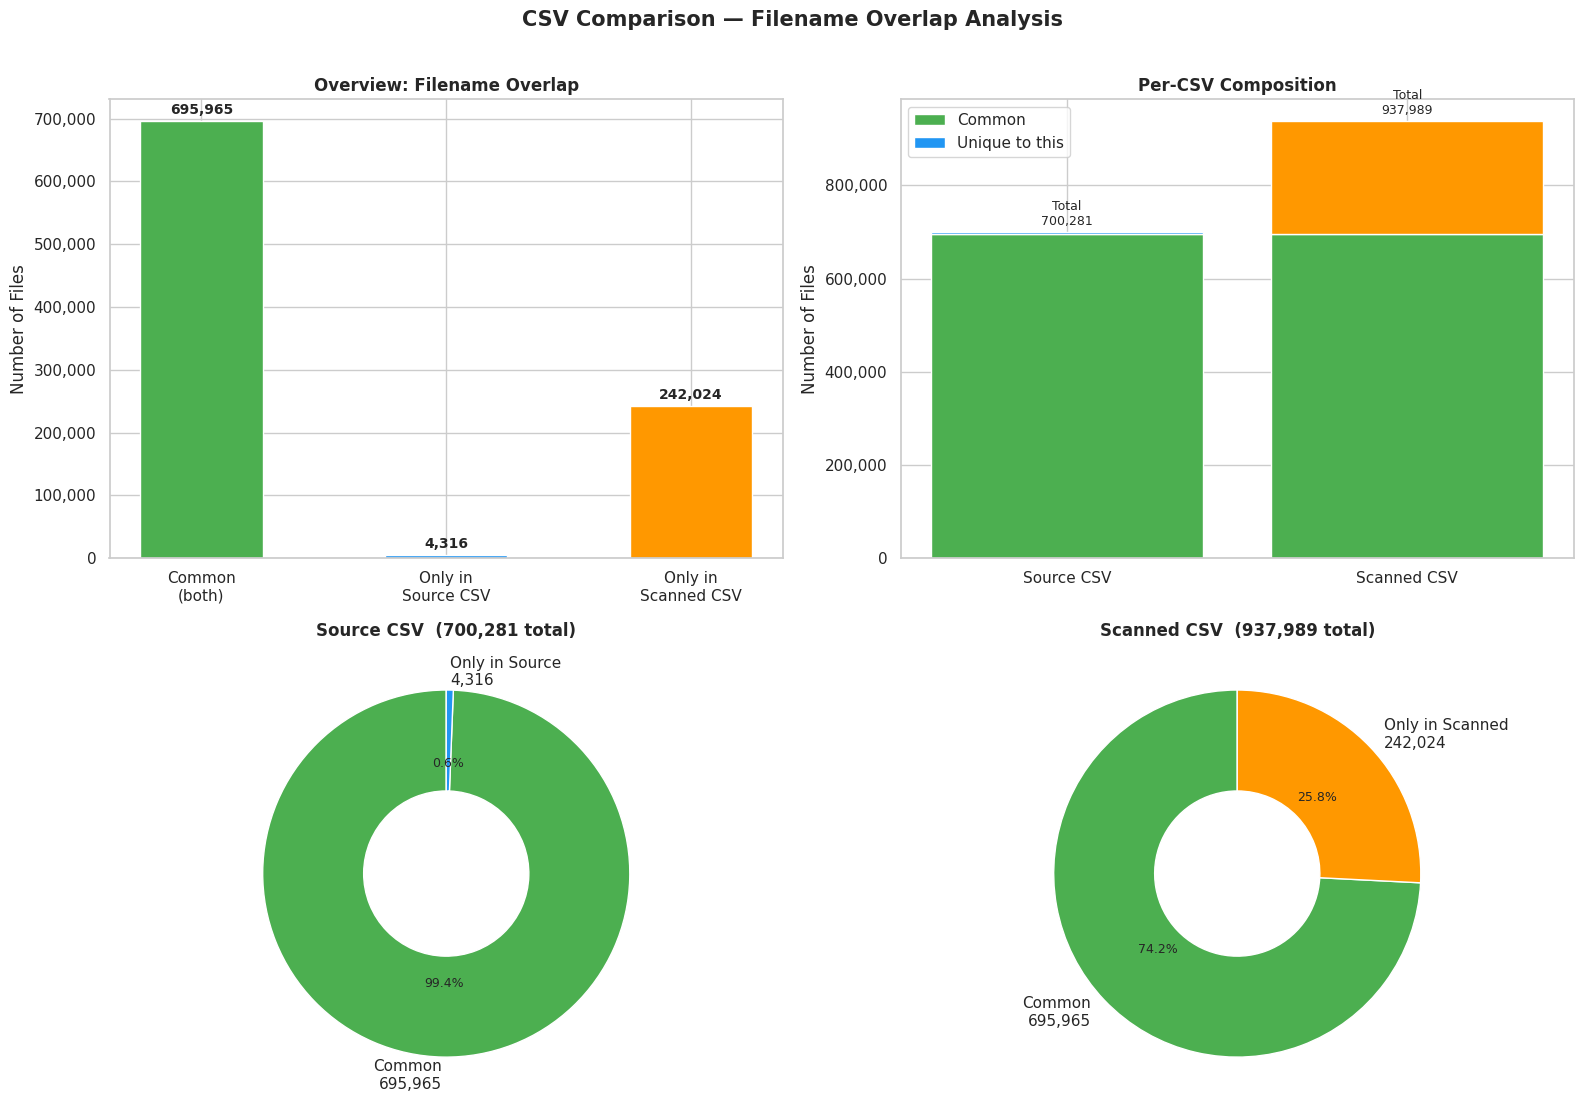


  Charts saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/03.compare_charts.png


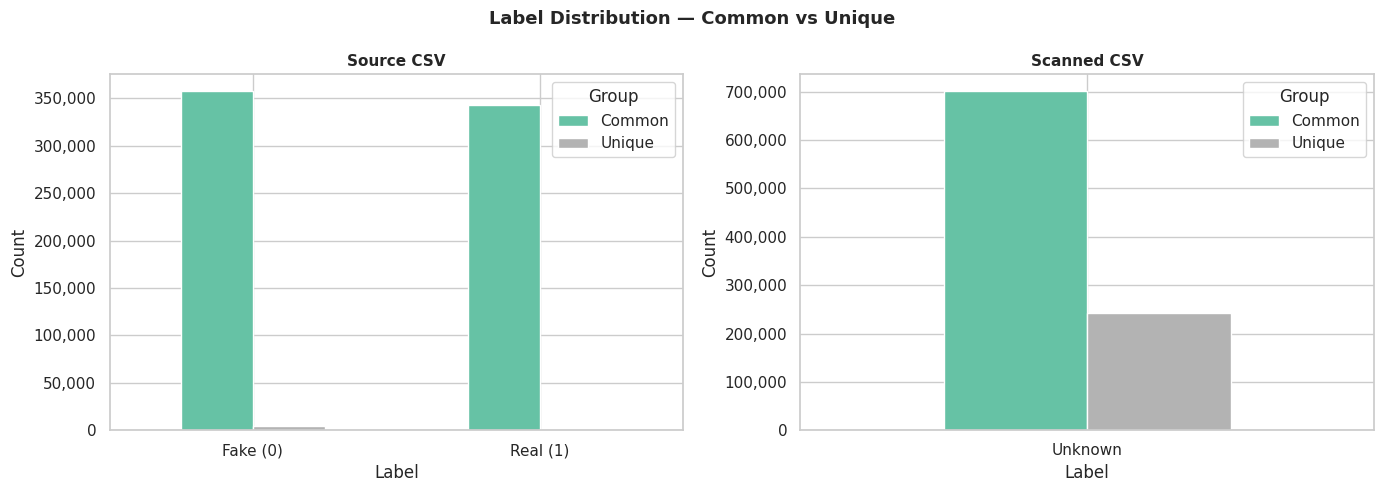

  Label breakdown saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/03.compare_label_breakdown.png


In [38]:
# CSVs   → data/processed/<PROJECT_NAME>/csv/03.compare_*.csv
# Charts → data/processed/<PROJECT_NAME>/charts/03.compare_*.png
results = compare_csvs(
    df_source   = df_source,    # DataFrame from Step 1  (or pass a CSV path)
    df_scanned  = df_scanned,   # DataFrame from Step 2a or 2b
    compare_col = "filename",
    prefix      = "03",
)

# results["common"]          → set of filenames in both
# results["only_in_source"]  → set of filenames only in source CSV
# results["only_in_scanned"] → set of filenames only in scanned CSV

## Step 3b — Compare Scanned Images vs Validation CSV

Checks whether the locally-scanned (or Wasabi-scanned) images appear in the **validation split**.  
Useful for detecting data leakage: images present in both the scanned dataset and the val CSV.

Val CSV     : /home/taiaburrahman/dataset_manager_pro/data/csv/GAID_Dataset_v9_full_Val.csv
Val rows    : 63,582
Scanned rows: 942,769

╔──────────────────────────────────────────────────────────────────────╗
║  STEP 3 — CSV COMPARISON  [project: GAID-v9]                         ║
╠──────────────────────────────────────────────────────────────────────╣
║  Compare column       : 'filename'                                   ║
╠──────────────────────────────────────────────────────────────────────╣
║  Source CSV           :     63,578 unique filenames                  ║
║  Scanned CSV          :    937,989 unique filenames                  ║
╠──────────────────────────────────────────────────────────────────────╣
║  ✓  Common (both)     :     63,419                                   ║
║  ◀  Only in source    :        159                                   ║
║  ▶  Only in scanned   :    874,570                                   ║
╠────────────────────────────────────────────────────────────

,filename,labels
0,birdclef25/Tapera_naevia.jpg,1
2,real_faces_mtv_images/2024-11-10_19-51-25_UTC_2.jpg,1
3,INPUT_IMAGES/a2233-_I2E8955_P1.JPG,1
4,real/03d1ccc681f34957b7342b095ebb0090.jpg,1
5,Gen_samples_Grok3_220325/BFtKFKhrBf9BKBCq-generated_image.jpg,0
6,real/00a70a81240743c58c5ac55f94fc6d74.jpg,1
7,real/ff7e0dba88fd4dde9cba126ee0e168b4.jpg,1
8,fake/18f2b28537d34e5ba5f7d425ed7ccae4.jpg,0
9,Gen_samples_Grok3_180325/image_8125.jpg,0
10,real/image_08995.png,1



── Sample: only in SOURCE csv (first 10) ──


,filename,labels
1,code_gen_100325/b68b5fed-6072-4fcd-abcf-f930ad4f977e.jpg,0
67,humangen_nature_070325/Gemini_Generated_Image_kt5td3kt5td3kt5t.jpg,0
147,code_gen_100325/2042d7e4-98b8-415d-934e-68dc3085e277.jpg,0
243,code_gen_100325/35199f77-90ba-44d5-92a2-3db4470c200e.jpg,0
283,code_gen_100325/3443ef2c-7587-42ce-84e7-28452f661dce.jpg,0
338,code_gen_100325/586c92c9-8845-4570-968c-f7c471acb10d.jpg,0
352,code_gen_100325/16d6dd95-99b1-483a-954f-87abef1c635b.jpg,0
385,code_gen_100325/a8786733-4365-480a-a5ce-527a513cec97.jpg,0
403,code_gen_100325/b149d060-aa84-44bc-89de-5f4f7610d2ad.jpg,0
431,humangen_nature_070325/Gemini_Generated_Image_97a7nv97a7nv97a7.jpg,0



── Sample: only in SCANNED csv (first 10) ──


,filename,labels
0,selected_Real_Samples_phase_2/1a104c22-26a4-4155-9836-9d1cf0e1516a.jpg,0.0
1,selected_Real_Samples_phase_2/3f95cc26-15a5-453a-88e3-a6e9e70f4ad5.jpg,0.0
2,selected_Real_Samples_phase_2/646fb0a7-70ba-4285-942c-8ff3c2b7e292.jpg,0.0
3,selected_Real_Samples_phase_2/fca386c2-9a14-48ff-8fdb-f1a1ce44c040.jpg,0.0
4,selected_Real_Samples_phase_2/5e3de63f-948c-4738-a5fd-f4382dd1bc05.jpg,0.0
5,selected_Real_Samples_phase_2/a4cd4e36-87b0-4091-a11b-eb744adb96c5.jpg,0.0
6,selected_Real_Samples_phase_2/8bbb5aec-4383-4f63-bcf9-ac12e1b534b3.jpg,0.0
7,selected_Real_Samples_phase_2/dc7772bd-c3e4-44a6-bdc4-a8ae84626b04.jpg,0.0
8,selected_Real_Samples_phase_2/836b7b06-f11d-4858-9bd6-d74d9a74f071.jpg,0.0
9,selected_Real_Samples_phase_2/757f2de4-be7a-4a69-a2b4-be0be6a15c22.jpg,0.0


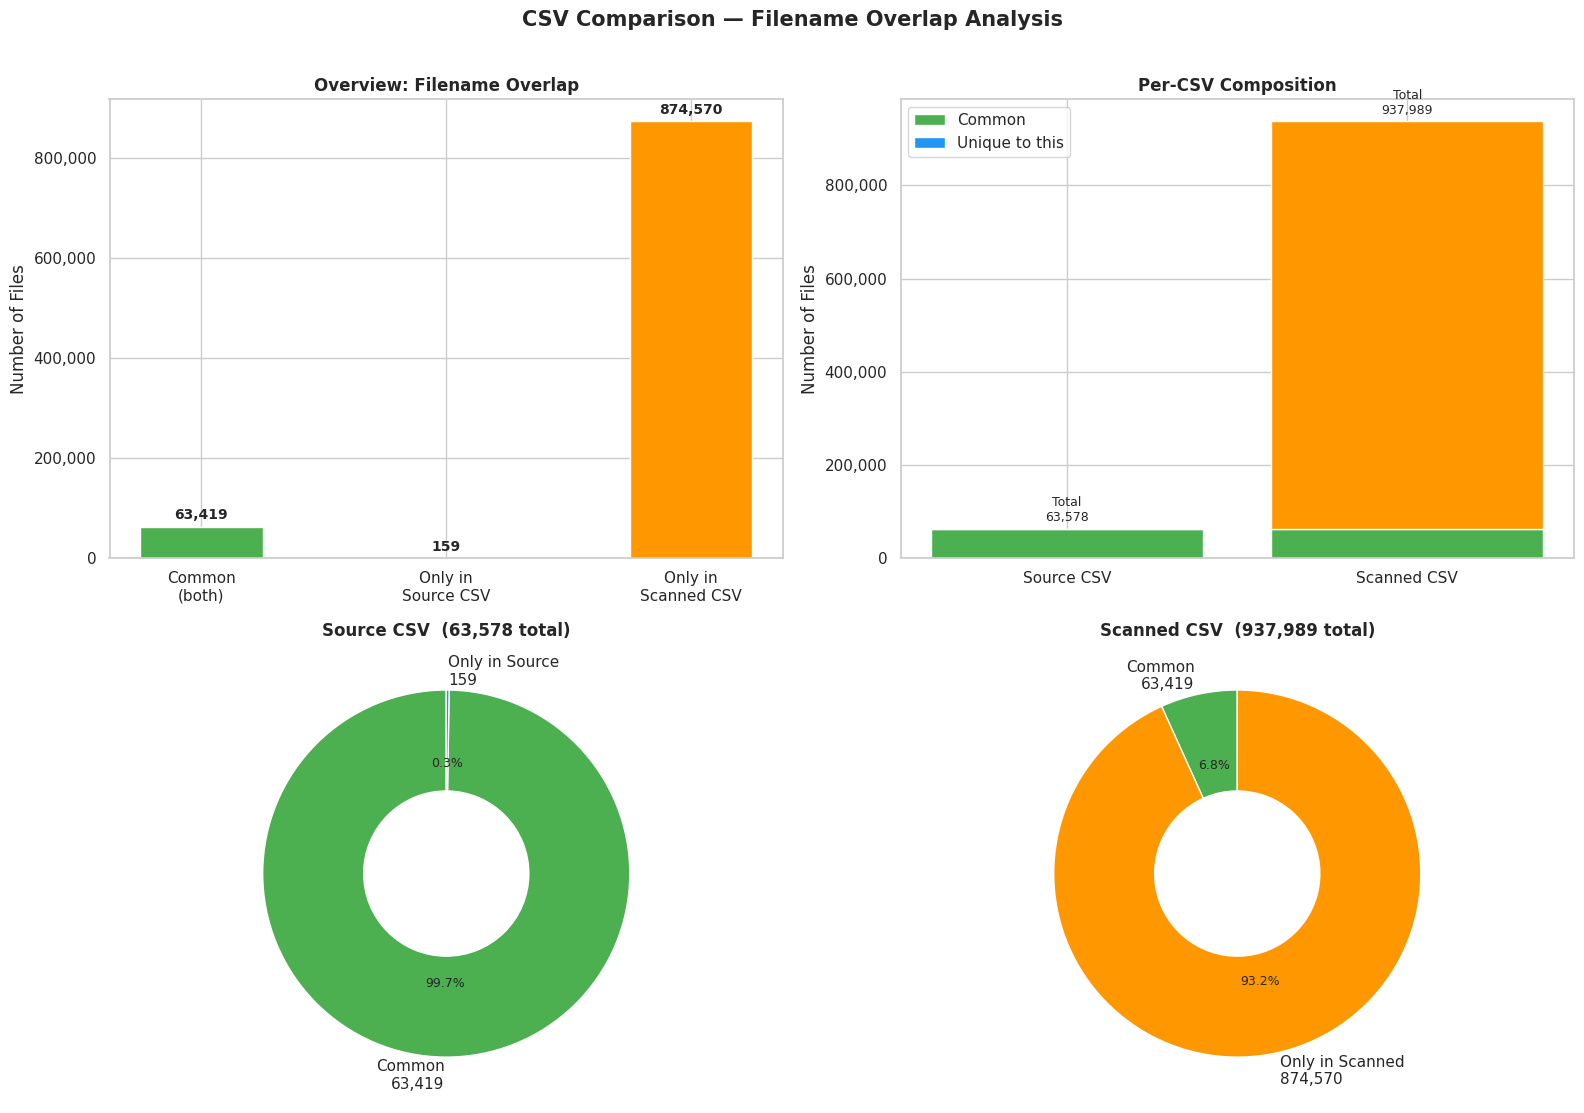


  Charts saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/04.compare_charts.png


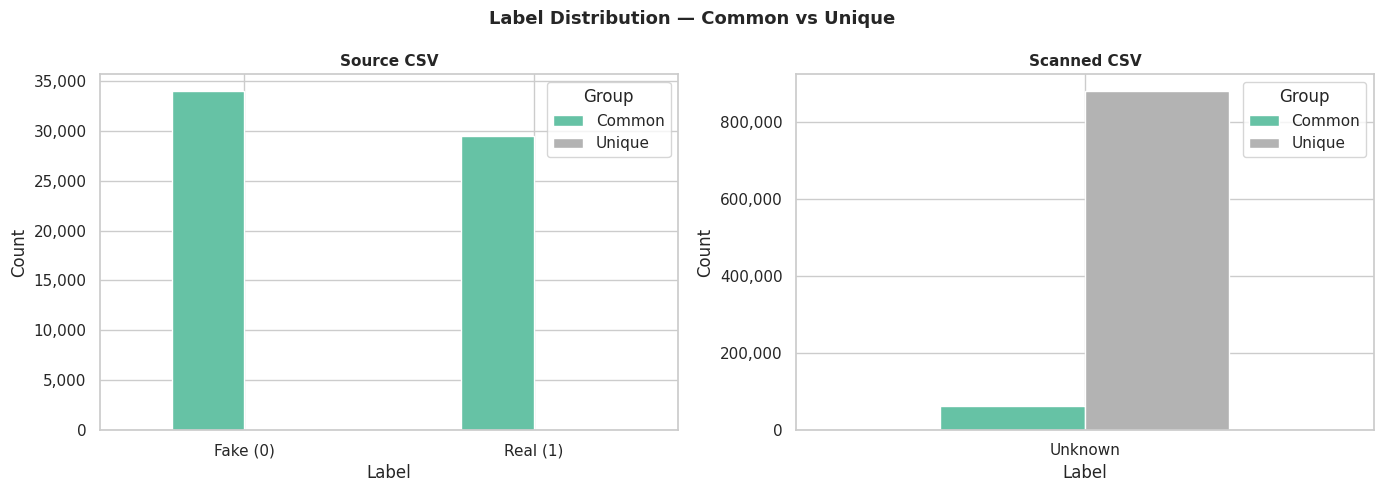

  Label breakdown saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/04.compare_label_breakdown.png


In [39]:
# Load the validation CSV and add a filename column (same as Step 1)
df_val = pd.read_csv(VAL_CSV)
if "filename" not in df_val.columns:
    df_val["filename"] = df_val["image_path"].apply(_rel_name)

print(f"Val CSV     : {VAL_CSV}")
print(f"Val rows    : {len(df_val):,}")
print(f"Scanned rows: {len(df_scanned):,}\n")

# CSVs   → data/processed/<PROJECT_NAME>/csv/04.compare_*.csv
# Charts → data/processed/<PROJECT_NAME>/charts/04.compare_*.png
results_val = compare_csvs(
    df_source   = df_val,       # validation CSV as the reference
    df_scanned  = df_scanned,   # DataFrame from Step 2a or 2b
    compare_col = "filename",
    prefix      = "04",
)

# results_val["common"]          → images present in BOTH scanned and val
# results_val["only_in_source"]  → in val but NOT in scanned dataset
# results_val["only_in_scanned"] → in scanned dataset but NOT in val

## Appendix — Re-run Comparison from Saved CSVs

If you've already run Steps 1 & 2 in a previous session, load the saved CSVs directly:

Project  : GAID-v9
CSV A    : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/csv/01.GAID_Dataset_v9_full_Train_with_filename.csv
CSV B    : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/csv/02.GAID-v9_local_scanned.csv

Loading source  CSV …


Loading scanned CSV …
╔──────────────────────────────────────────────────────────────────────╗
║  STEP 3 — CSV COMPARISON  [project: GAID-v9]                         ║
╠──────────────────────────────────────────────────────────────────────╣
║  Compare column       : 'filename'                                   ║
╠──────────────────────────────────────────────────────────────────────╣
║  Source CSV           :    700,281 unique filenames                  ║
║  Scanned CSV          :    937,989 unique filenames                  ║
╠──────────────────────────────────────────────────────────────────────╣
║  ✓  Common (both)     :    695,965                                   ║
║  ◀  Only in source    :      4,316                                   ║
║  ▶  Only in scanned   :    242,024                                   ║
╠──────────────────────────────────────────────────────────────────────╣
║  CSV dir              : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/csv║
║  Chart

,filename,labels
0,real/0e35d3c709ef4123bb7b8cff23c885a4.jpg,1
1,real/12905.jpg,1
2,fake/1085.jpg,0
3,real/image_05650.png,1
4,fake/d3c613a6d9574f55b3854643c5ca2374.jpg,0
5,fake/2839.jpg,0
7,Gen_samples_Grok3_180325/image - 2025-03-18T102548.813.jpg,0
8,real/de2d9174de90417d9c7973a890ef7466.jpg,1
9,Gen_samples_Gemini_190325/4a0bd30a-24d4-4d7c-9594-28c97d7a55ac.jpg,0
10,fake/4cb2b6aec83a4968969fe57813deee04.jpg,0



── Sample: only in SOURCE csv (first 10) ──


,filename,labels
6,code_gen_100325/5a3fcafb-5fe4-4781-8e76-16df69bc572d.jpg,0
16,code_gen_100325/df70f4a5-872e-472d-96d4-51c91908be04.jpg,0
45,code_gen_100325/b18adf02-277d-4dd6-8089-311e57930d48.jpg,0
79,code_gen_100325/51f5aa72-6e7c-4f4d-90b2-38dd3ca7675b.jpg,0
80,humangen_nature_070325/481926019_1717227128862026_5355939177462596462_n.jpg,0
119,humangen_nature_070325/Gemini_Generated_Image_oskkzroskkzroskk.jpg,0
139,code_gen_100325/0b52cef5-6979-44d9-b47a-8bd1d51baae7.jpg,0
199,code_gen_100325/b068f404-e361-4178-a1d4-173afb943dcf.jpg,0
208,code_gen_100325/f1c711d0-0c36-48af-b3a6-f3bed0fd59f4.jpg,0
284,code_gen_100325/f63d7e71-455e-4230-9e12-7b8df4a57d58.jpg,0



── Sample: only in SCANNED csv (first 10) ──


,filename,labels
0,selected_Real_Samples_phase_2/1a104c22-26a4-4155-9836-9d1cf0e1516a.jpg,0.0
1,selected_Real_Samples_phase_2/3f95cc26-15a5-453a-88e3-a6e9e70f4ad5.jpg,0.0
2,selected_Real_Samples_phase_2/646fb0a7-70ba-4285-942c-8ff3c2b7e292.jpg,0.0
3,selected_Real_Samples_phase_2/fca386c2-9a14-48ff-8fdb-f1a1ce44c040.jpg,0.0
4,selected_Real_Samples_phase_2/5e3de63f-948c-4738-a5fd-f4382dd1bc05.jpg,0.0
5,selected_Real_Samples_phase_2/a4cd4e36-87b0-4091-a11b-eb744adb96c5.jpg,0.0
6,selected_Real_Samples_phase_2/8bbb5aec-4383-4f63-bcf9-ac12e1b534b3.jpg,0.0
7,selected_Real_Samples_phase_2/dc7772bd-c3e4-44a6-bdc4-a8ae84626b04.jpg,0.0
8,selected_Real_Samples_phase_2/836b7b06-f11d-4858-9bd6-d74d9a74f071.jpg,0.0
9,selected_Real_Samples_phase_2/757f2de4-be7a-4a69-a2b4-be0be6a15c22.jpg,0.0


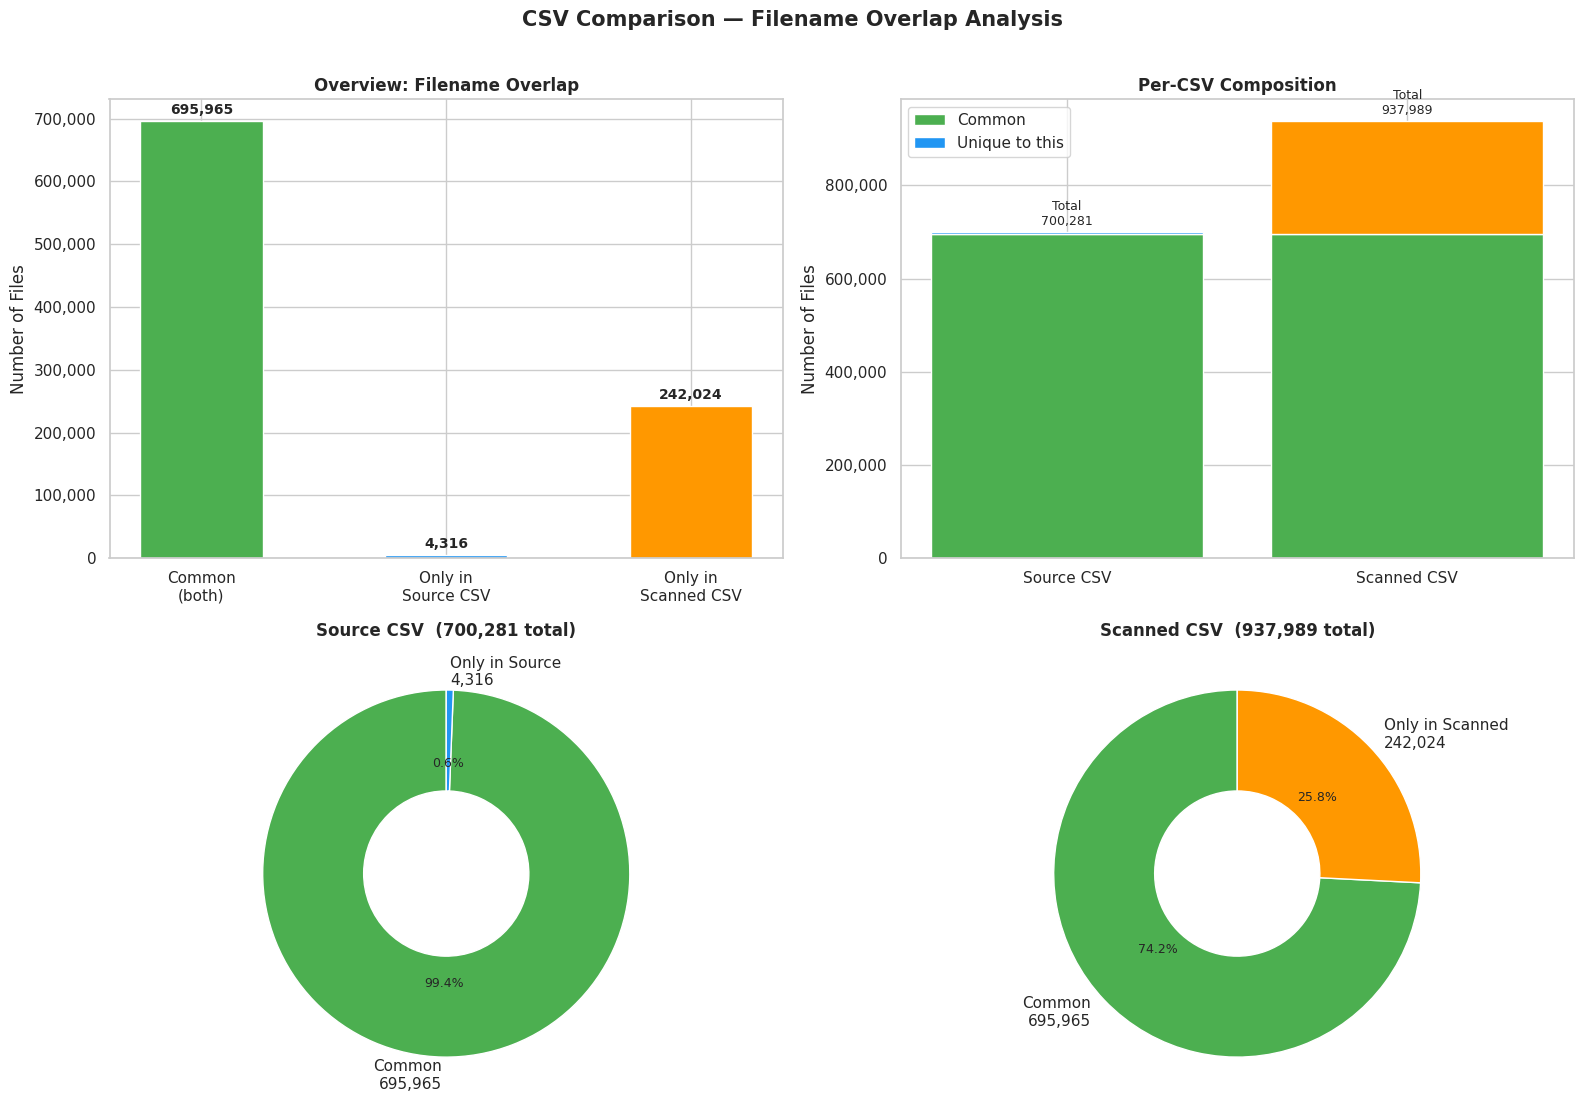


  Charts saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/03.compare_charts.png


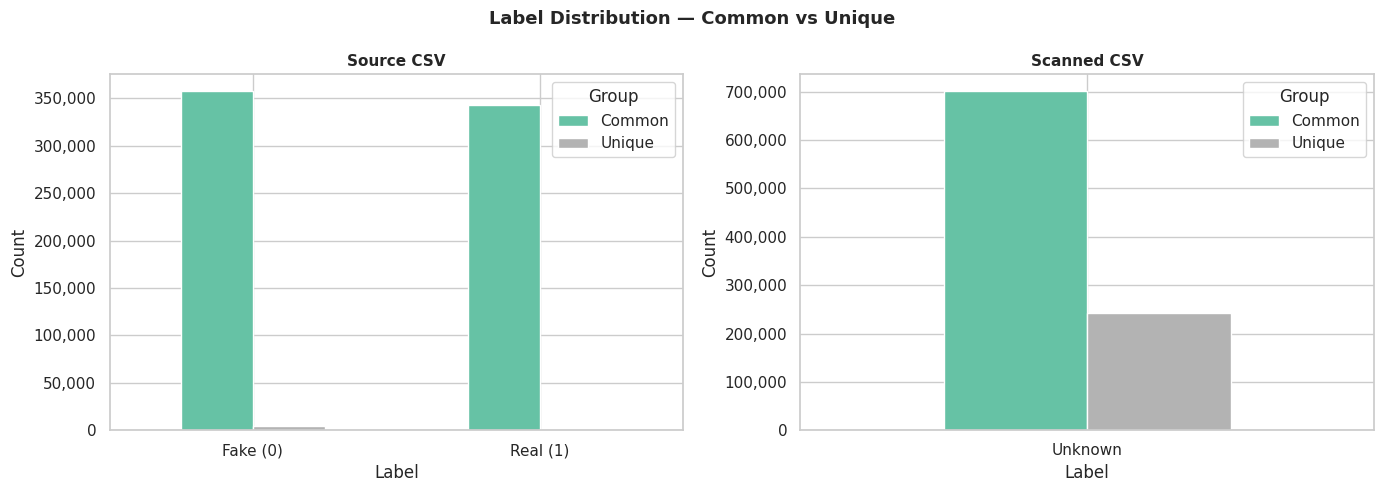

  Label breakdown saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/03.compare_label_breakdown.png


In [40]:
# ── INPUT ──────────────────────────────────────────────────────────────────
# Paths auto-resolve from PROJECT_NAME — change only if loading from elsewhere
CSV_A = CSV_DIR / f"01.{Path(SOURCE_CSV).stem}_with_filename.csv"
CSV_B = CSV_DIR / f"02.{PROJECT_NAME}_local_scanned.csv"   # or 02.<PROJECT_NAME>_wasabi_scanned.csv
# ───────────────────────────────────────────────────────────────────────────

print(f"Project  : {PROJECT_NAME}")
print(f"CSV A    : {CSV_A}")
print(f"CSV B    : {CSV_B}\n")

results = compare_csvs(
    df_source   = CSV_A,
    df_scanned  = CSV_B,
    compare_col = "filename",
    prefix      = "03",
)

---
## 7 — Dataset Analysis

Analyse **one or two** CSV files (e.g. train + val splits).  
Set `VAL_CSV = None` if you only have a single file.

Produces per-split and combined reports:
- Shape, label counts & percentages  
- Source dataset / directory breakdown  
- File-extension distribution  
- Train ↔ Val filename overlap (when both provided)  
- All charts saved to `data/processed/<PROJECT_NAME>/charts/`

In [41]:
# ── INPUT — Analysis config ────────────────────────────────────────────────
TRAIN_CSV = "/home/taiaburrahman/dataset_manager_pro/data/csv/GAID_Dataset_v9_full_Train.csv"
VAL_CSV   = "/home/taiaburrahman/dataset_manager_pro/data/csv/GAID_Dataset_v9_full_Val.csv"
# Set VAL_CSV = None for single-file analysis:
# VAL_CSV = None

# Column names (edit if your CSV uses different names)
PATH_COL  = "image_path"
LABEL_COL = "labels"
LABEL_NAMES = {"0": "Fake (AI)", "1": "Real"}

# How many top source directories to show in charts
TOP_N_SOURCES = 15

# ── Derived analysis output dirs ───────────────────────────────────────────
_analysis_charts = globals().get("CHARTS_DIR", Path("./charts"))
_analysis_charts.mkdir(parents=True, exist_ok=True)

# ── Path validation (catches typos before pandas opens the file) ────────────
_CSV_DIR = Path("/home/taiaburrahman/dataset_manager_pro/data/csv")
_available = sorted(_CSV_DIR.glob("*.csv"))

def _check_csv(p, label):
    if p is None:
        print(f"  {label:10s}: None  (single-file mode)")
        return True
    path = Path(p)
    if path.exists():
        rows_hint = ""
        print(f"  {label:10s}: ✓  {path.name}")
        return True
    print(f"  {label:10s}: ✗  NOT FOUND → {path.name}")
    print(f"               Available in {_CSV_DIR}:")
    for f in _available:
        print(f"                 • {f.name}")
    return False

print("─" * 60)
_ok_train = _check_csv(TRAIN_CSV, "TRAIN_CSV")
_ok_val   = _check_csv(VAL_CSV,   "VAL_CSV")
print(f"  Charts  →  : {_analysis_charts}")
print("─" * 60)

if not (_ok_train and _ok_val):
    raise FileNotFoundError(
        "One or more CSV paths above do not exist. "
        "Fix TRAIN_CSV / VAL_CSV and re-run this cell."
    )

────────────────────────────────────────────────────────────
  TRAIN_CSV : ✓  GAID_Dataset_v9_full_Train.csv
  VAL_CSV   : ✓  GAID_Dataset_v9_full_Val.csv
  Charts  →  : /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts
────────────────────────────────────────────────────────────


In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET ANALYSIS — helpers & main runner
# ══════════════════════════════════════════════════════════════════════════════

def _load_split(path: str | Path, split_name: str) -> pd.DataFrame:
    """Load a CSV split and add helper columns."""
    p  = Path(path)
    print(f"  Loading {split_name} ({p.name}) …", end=" ", flush=True)
    df = pd.read_csv(p, dtype=str, low_memory=False)
    df["_split"]     = split_name
    df["_filename"]  = df[PATH_COL].apply(_rel_name)
    df["_ext"]       = df[PATH_COL].apply(lambda x: Path(str(x)).suffix.lower())
    # source: 3rd-last path component (dataset origin folder)
    def _src(p_str):
        parts = Path(str(p_str)).parts
        return parts[-3] if len(parts) >= 3 else parts[-2] if len(parts) >= 2 else "unknown"
    df["_source"] = df[PATH_COL].apply(_src)
    print(f"{len(df):,} rows")
    return df


def _label_str(df: pd.DataFrame) -> pd.Series:
    return df[LABEL_COL].map(LABEL_NAMES).fillna(df[LABEL_COL])


def _print_split_summary(df: pd.DataFrame, name: str):
    lc   = df[LABEL_COL].value_counts().sort_index()
    total = len(df)
    rows = [f"SPLIT: {name}", "---",
            f"Total rows      : {total:,}",
            f"Unique filenames : {df['_filename'].nunique():,}",
            f"File extensions : {sorted(df['_ext'].unique())}",
            "---"]
    for lbl, cnt in lc.items():
        name_str = LABEL_NAMES.get(lbl, lbl)
        rows.append(f"  Label {lbl} ({name_str:<10}): {cnt:>8,}  ({cnt/total*100:.1f}%)")
    print(_box(rows))


def _chart_label_dist(splits: dict[str, pd.DataFrame], save_dir: Path, pfx: str = "05"):
    """Bar + Pie charts for label distribution per split."""
    n     = len(splits)
    fig, axes = plt.subplots(n, 2, figsize=(13, 4.5 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle("Label Distribution", fontsize=14, fontweight="bold", y=1.01)

    PAL = {"Fake (AI)": "#E74C3C", "Real": "#2ECC71",
           "Fake": "#E74C3C", "Unknown": "#95A5A6"}

    for row_ax, (sname, df) in zip(axes, splits.items()):
        ax_bar, ax_pie = row_ax
        lc      = df[LABEL_COL].value_counts().sort_index()
        lbls    = [LABEL_NAMES.get(k, str(k)) for k in lc.index]
        colors  = [PAL.get(l, "#3498DB") for l in lbls]
        total   = len(df)

        # Bar
        bars = ax_bar.bar(lbls, lc.values, color=colors, edgecolor="white", width=0.5)
        for b, v in zip(bars, lc.values):
            ax_bar.text(b.get_x() + b.get_width()/2, v + total*0.005,
                        f"{v:,}\n({v/total*100:.1f}%)",
                        ha="center", va="bottom", fontsize=9)
        ax_bar.set_title(f"{sname}  ({total:,} rows)", fontweight="bold")
        ax_bar.set_ylabel("Count")
        ax_bar.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x):,}"))
        ax_bar.set_ylim(0, max(lc.values) * 1.18)

        # Pie
        ax_pie.pie(lc.values, labels=lbls, colors=colors, autopct="%1.1f%%",
                   startangle=90, wedgeprops=dict(width=0.6, edgecolor="white"))
        ax_pie.set_title(f"{sname} — proportion", fontweight="bold")

    plt.tight_layout()
    p = save_dir / f"{_pfx(pfx)}analysis_label_dist.png"
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved → {p}")


def _chart_source_dist(splits: dict[str, pd.DataFrame], save_dir: Path, top_n: int = 15, pfx: str = "05"):
    """Horizontal bar chart of top source directories per split."""
    n   = len(splits)
    fig, axes = plt.subplots(1, n, figsize=(9 * n, max(6, top_n * 0.45)))
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Top {top_n} Source Directories", fontsize=14, fontweight="bold")

    for ax, (sname, df) in zip(axes, splits.items()):
        src_counts = df["_source"].value_counts().head(top_n)
        colors     = plt.cm.tab20.colors[:len(src_counts)]
        ax.barh(src_counts.index[::-1], src_counts.values[::-1],
                color=colors[::-1], edgecolor="white")
        for i, (idx, val) in enumerate(zip(src_counts.index[::-1], src_counts.values[::-1])):
            ax.text(val + src_counts.values.max() * 0.01, i,
                    f"{val:,}", va="center", fontsize=8)
        ax.set_title(f"{sname}", fontweight="bold")
        ax.set_xlabel("Count")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x):,}"))
        ax.set_xlim(0, src_counts.values.max() * 1.15)

    plt.tight_layout()
    p = save_dir / f"{_pfx(pfx)}analysis_source_dist.png"
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved → {p}")


def _chart_source_by_label(splits: dict[str, pd.DataFrame], save_dir: Path, top_n: int = 12, pfx: str = "05"):
    """Stacked bar: top sources coloured by label."""
    PAL = {"0": "#E74C3C", "1": "#2ECC71"}

    for sname, df in splits.items():
        top_src = df["_source"].value_counts().head(top_n).index
        grp = (df[df["_source"].isin(top_src)]
               .groupby(["_source", LABEL_COL])
               .size().unstack(fill_value=0)
               .loc[top_src])

        fig, ax = plt.subplots(figsize=(14, 5))
        grp.plot(kind="bar", ax=ax, color=[PAL.get(c, "#95A5A6") for c in grp.columns],
                 edgecolor="white", stacked=False)
        ax.set_title(f"{sname} — Label Distribution by Source (top {top_n})",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x):,}"))
        handles = [plt.Rectangle((0,0),1,1, color=PAL.get(k,"#95A5A6"))
                   for k in grp.columns]
        labels  = [LABEL_NAMES.get(k, str(k)) for k in grp.columns]
        ax.legend(handles, labels, title="Label")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        p = save_dir / f"{_pfx(pfx)}analysis_source_by_label_{sname.lower().replace(' ','_')}.png"
        plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
        print(f"  Saved → {p}")


def _chart_ext_dist(splits: dict[str, pd.DataFrame], save_dir: Path, pfx: str = "05"):
    """File-extension distribution per split."""
    fig, ax = plt.subplots(figsize=(10, 4))
    all_exts = pd.concat([
        df["_ext"].value_counts().rename(sname) for sname, df in splits.items()
    ], axis=1).fillna(0).astype(int)
    all_exts.plot(kind="bar", ax=ax, edgecolor="white")
    ax.set_title("File Extension Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel("Extension")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x):,}"))
    plt.xticks(rotation=0)
    plt.tight_layout()
    p = save_dir / f"{_pfx(pfx)}analysis_ext_dist.png"
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved → {p}")


def _chart_overlap(df_train: pd.DataFrame, df_val: pd.DataFrame, save_dir: Path, pfx: str = "05"):
    """Venn-style bar showing train/val filename overlap."""
    t_files = set(df_train["_filename"])
    v_files = set(df_val["_filename"])
    common  = t_files & v_files
    only_t  = t_files - v_files
    only_v  = v_files - t_files

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Train ↔ Val Filename Overlap", fontsize=13, fontweight="bold")

    # Bar
    ax = axes[0]
    cats   = ["Common\n(both)", "Only Train", "Only Val"]
    counts = [len(common), len(only_t), len(only_v)]
    colors = ["#4CAF50", "#2196F3", "#FF9800"]
    bars   = ax.bar(cats, counts, color=colors, edgecolor="white", width=0.5)
    for b, v in zip(bars, counts):
        ax.text(b.get_x()+b.get_width()/2, v + max(counts)*0.01,
                f"{v:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylabel("Filenames")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x):,}"))
    ax.set_title("Count by overlap group")

    # Stacked per-split
    ax = axes[1]
    ax.bar(["Train"], [len(common)],  color="#4CAF50", label="Common",     edgecolor="white")
    ax.bar(["Train"], [len(only_t)],  color="#2196F3", label="Only Train", edgecolor="white",
           bottom=[len(common)])
    ax.bar(["Val"],   [len(common)],  color="#4CAF50", edgecolor="white")
    ax.bar(["Val"],   [len(only_v)],  color="#FF9800", label="Only Val",   edgecolor="white",
           bottom=[len(common)])
    ax.set_ylabel("Filenames")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{int(x):,}"))
    ax.set_title("Composition of each split")
    ax.legend()
    plt.tight_layout()
    p = save_dir / f"{_pfx(pfx)}analysis_train_val_overlap.png"
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved → {p}")

    # Text summary
    print(_box([
        "TRAIN ↔ VAL OVERLAP", "---",
        f"Train unique filenames : {len(t_files):>10,}",
        f"Val   unique filenames : {len(v_files):>10,}",
        "---",
        f"✓  Common (both)       : {len(common):>10,}  ({len(common)/len(t_files)*100:.2f}% of train)",
        f"◀  Only in Train       : {len(only_t):>10,}",
        f"▶  Only in Val         : {len(only_v):>10,}",
        "---",
        "⚠  Leakage risk: " + ("YES — overlap found!" if common else "None detected ✓"),
    ]))
    return common


def run_analysis(
    train_csv: str | Path,
    val_csv:   str | Path | None = None,
    save_dir:  Path | None = None,
    top_n:     int = 15,
    prefix:    str = "05",
) -> dict:
    """
    Full EDA for a single CSV or train+val pair.

    Parameters
    ----------
    train_csv : Path to the training (or only) CSV file.
    val_csv   : Path to the validation CSV. Pass None for single-file mode.
    save_dir  : Directory to save charts. Defaults to project CHARTS_DIR.
    top_n     : Number of top sources to show in distribution charts.
    prefix    : Numeric prefix for all chart filenames, e.g. '05' → '05.name.png'.

    Returns a dict with loaded DataFrames and overlap results.
    """
    save_dir = save_dir or globals().get("CHARTS_DIR", Path("./charts"))
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    sns.set_theme(style="whitegrid", palette="muted")
    print(f"\n{'═'*60}")
    print(f"  DATASET ANALYSIS  [project: {globals().get('PROJECT_NAME','?')}]")
    print(f"{'═'*60}\n")

    # ── Load ──────────────────────────────────────────────────────────────
    df_train = _load_split(train_csv, "Train")
    df_val   = _load_split(val_csv,   "Val") if val_csv else None

    splits = {"Train": df_train}
    if df_val is not None:
        splits["Val"] = df_val

    # ── Per-split text summaries ───────────────────────────────────────────
    print()
    for sname, df in splits.items():
        _print_split_summary(df, sname)

    # ── Combined summary (if both splits) ────────────────────────────────
    if df_val is not None:
        df_all = pd.concat([df_train, df_val], ignore_index=True)
        print(_box([
            "COMBINED (Train + Val)", "---",
            f"Total rows       : {len(df_all):,}",
            f"Unique filenames  : {df_all['_filename'].nunique():,}",
        ] + [
            f"  Label {k} ({LABEL_NAMES.get(k,k):<10}): {v:>8,}  ({v/len(df_all)*100:.1f}%)"
            for k, v in df_all[LABEL_COL].value_counts().sort_index().items()
        ]))

    # ── Charts ────────────────────────────────────────────────────────────
    print("\nGenerating charts …\n")
    _chart_label_dist(splits, save_dir, pfx=prefix)
    _chart_source_dist(splits, save_dir, top_n, pfx=prefix)
    _chart_source_by_label(splits, save_dir, min(top_n, 12), pfx=prefix)
    _chart_ext_dist(splits, save_dir, pfx=prefix)

    overlap = None
    if df_val is not None:
        print("\nOverlap analysis …")
        overlap = _chart_overlap(df_train, df_val, save_dir, pfx=prefix)

    print(f"\n✓ All charts saved to: {save_dir}")
    return {"train": df_train, "val": df_val, "overlap": overlap}


print("✓ Analysis helpers ready")

✓ Analysis helpers ready


## 8 — Run Analysis

Runs all stats and saves charts to `data/processed/<PROJECT_NAME>/charts/`.  
Set `VAL_CSV = None` in Cell 7 for single-file mode.


════════════════════════════════════════════════════════════
  DATASET ANALYSIS  [project: GAID-v9]
════════════════════════════════════════════════════════════

  Loading Train (GAID_Dataset_v9_full_Train.csv) … 704,779 rows
  Loading Val (GAID_Dataset_v9_full_Val.csv) … 63,582 rows

╔──────────────────────────────────────────────────────────────────────╗
║  SPLIT: Train                                                        ║
╠──────────────────────────────────────────────────────────────────────╣
║  Total rows      : 704,779                                           ║
║  Unique filenames : 700,281                                          ║
║  File extensions : ['.jpeg', '.jpg', '.png']                         ║
╠──────────────────────────────────────────────────────────────────────╣
║    Label 0 (Fake (AI) ):  361,715  (51.3%)                           ║
║    Label 1 (Real      ):  343,064  (48.7%)                           ║
╚───────────────────────────────────────────────────────

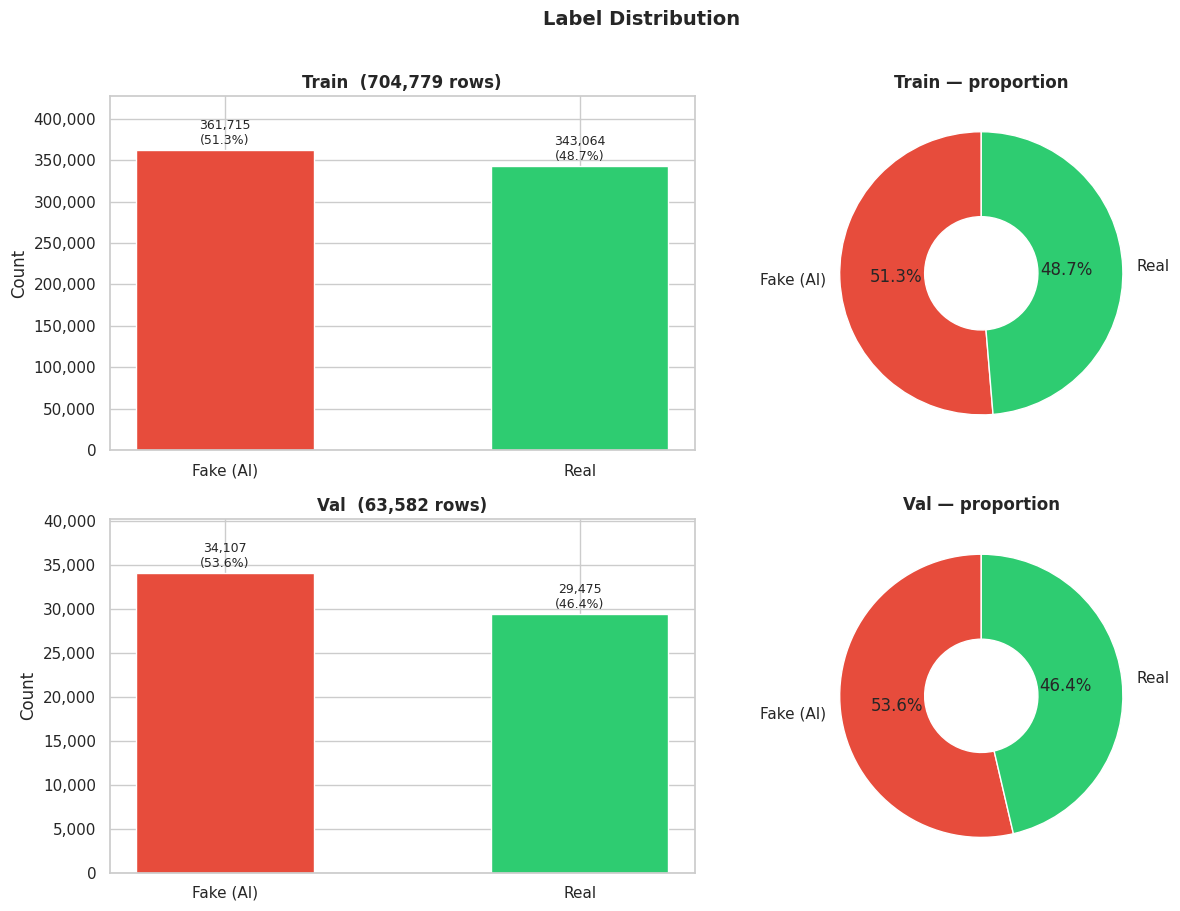

  Saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/05.analysis_label_dist.png


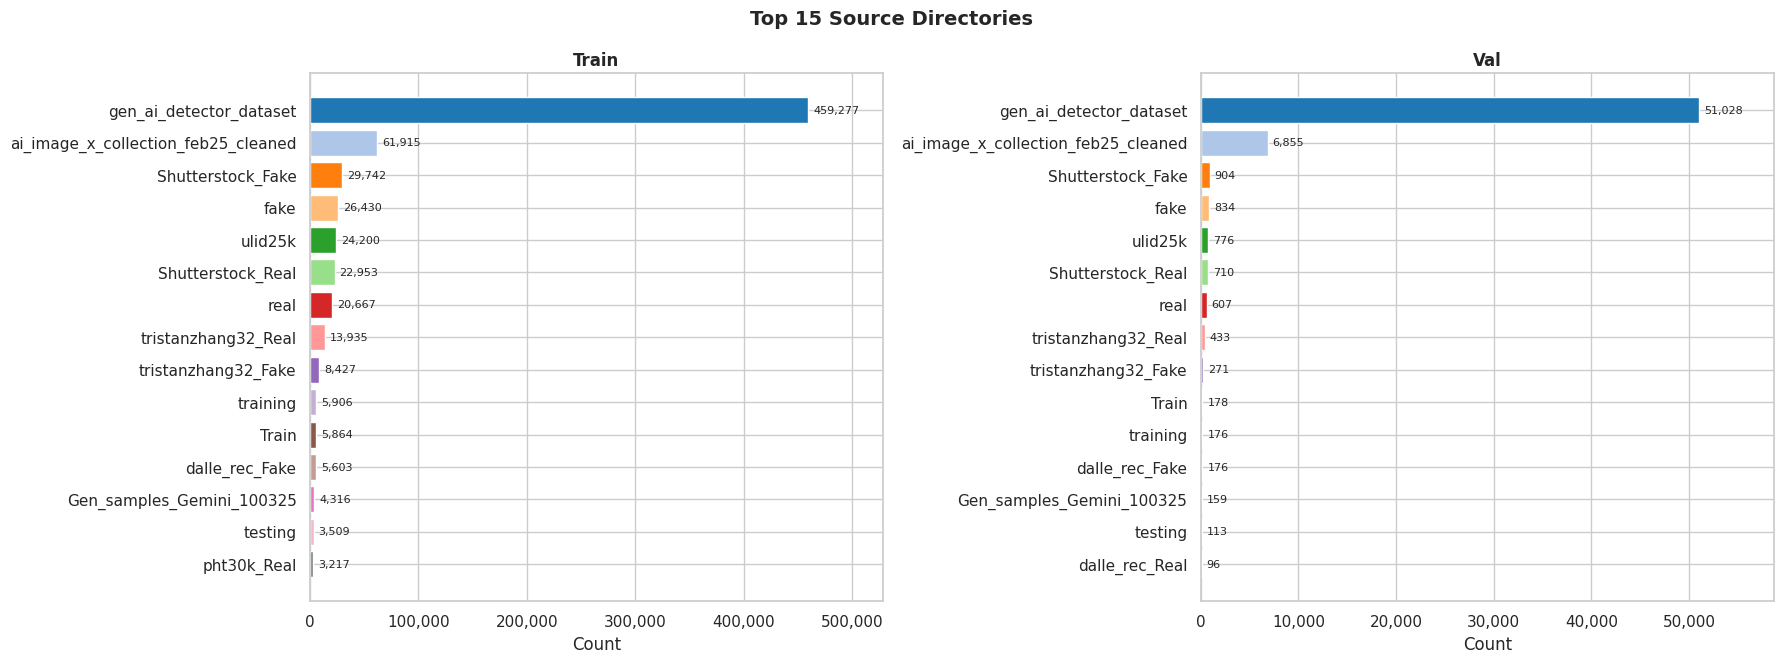

  Saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/05.analysis_source_dist.png


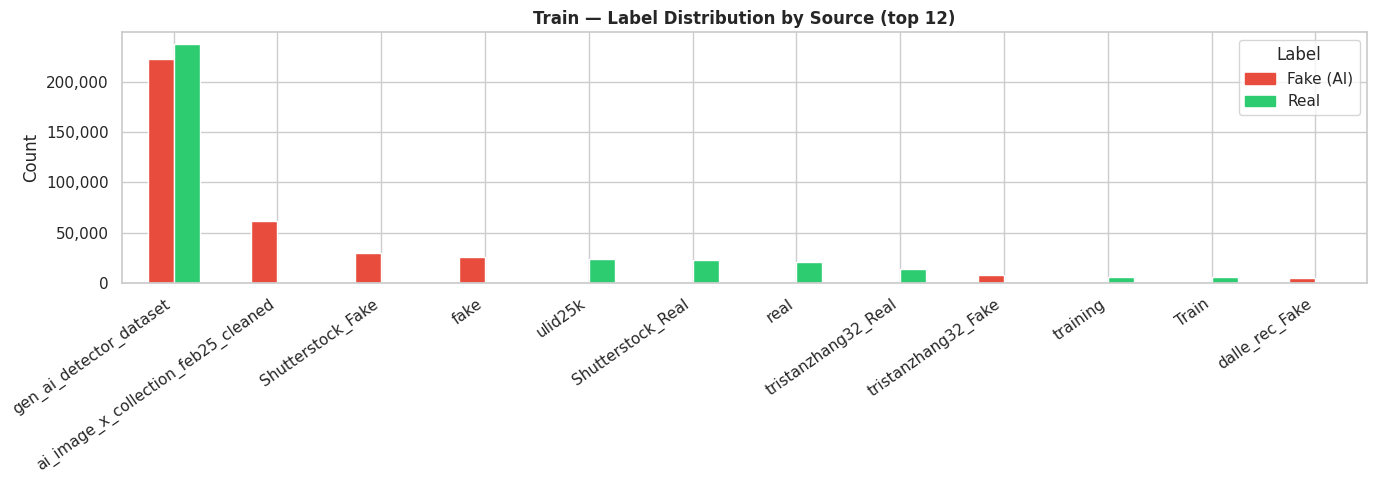

  Saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/05.analysis_source_by_label_train.png


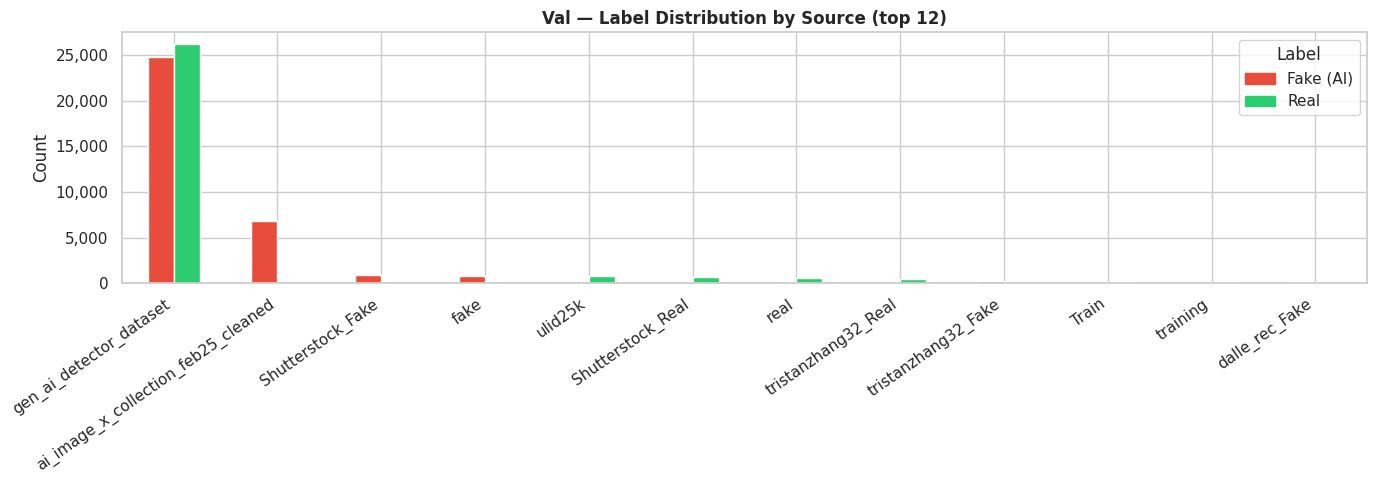

  Saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/05.analysis_source_by_label_val.png


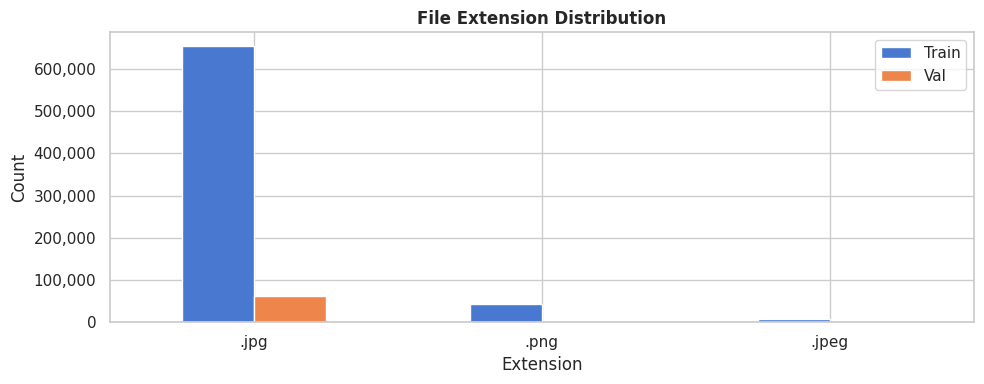

  Saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/05.analysis_ext_dist.png

Overlap analysis …


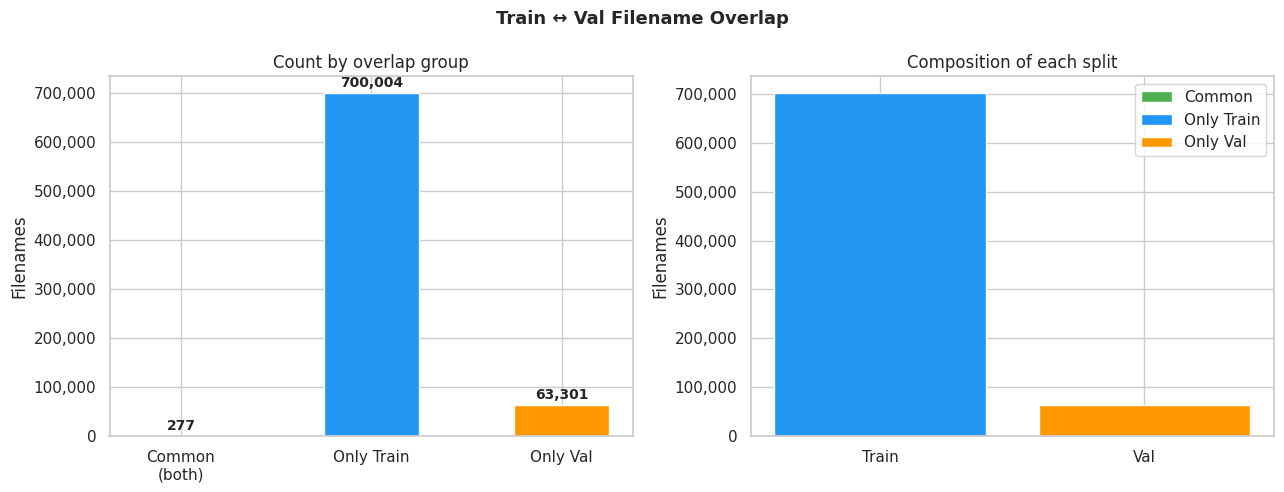

  Saved → /home/taiaburrahman/dataset_manager_pro/data/processed/GAID-v9/charts/05.analysis_train_val_overlap.png
╔──────────────────────────────────────────────────────────────────────╗
║  TRAIN ↔ VAL OVERLAP                                                 ║
╠──────────────────────────────────────────────────────────────────────╣
║  Train unique filenames :    700,281                                 ║
║  Val   unique filenames :     63,578                                 ║
╠──────────────────────────────────────────────────────────────────────╣
║  ✓  Common (both)       :        277  (0.04% of train)               ║
║  ◀  Only in Train       :    700,004                                 ║
║  ▶  Only in Val         :     63,301                                 ║
╠──────────────────────────────────────────────────────────────────────╣
║  ⚠  Leakage risk: YES — overlap found!                               ║
╚──────────────────────────────────────────────────────────────────────╝

✓ All cha

In [43]:
# Charts → data/processed/<PROJECT_NAME>/charts/05.analysis_*.png
analysis = run_analysis(
    train_csv = TRAIN_CSV,
    val_csv   = VAL_CSV,        # None → single-file mode
    top_n     = TOP_N_SOURCES,
    prefix    = "05",
)

# Loaded DataFrames are available afterwards:
#   analysis["train"]   → Train DataFrame
#   analysis["val"]     → Val DataFrame  (None in single-file mode)
#   analysis["overlap"] → set of common filenames (None in single-file mode)

---
## 9 — Missing Image Audit

Cross-references every image in `SOURCE_CSV` and `VAL_CSV` against the files actually present in `IMAGE_SCAN_DIR` (matched by **filename**).

Outputs per-split summaries and saves two CSVs:

| File | Contents |
|---|---|
| `missing_images_train.csv` | Rows from Train CSV whose filename was **not found** locally |
| `missing_images_val.csv` | Rows from Val CSV whose filename was **not found** locally |

Each CSV contains: `image_path` (original), `labels`, `filename`, `source_folder`

| Variable | Meaning |
|---|---|
| `LOCAL_DATA_ROOT` | Defaults to `IMAGE_SCAN_DIR` — the extracted local image directory |
| `SAVE_MISSING_CSV` | `True` → write missing-image rows to `CSV_DIR` |
| `SAVE_FOUND_CSV` | `True` → also write found-image rows (can be large) |

In [44]:
# ── INPUT ──────────────────────────────────────────────────────────────────
LOCAL_DATA_ROOT  = IMAGE_SCAN_DIR   # scanned/extracted local directory to match against
SAVE_MISSING_CSV = True             # save missing-image rows to CSV_DIR
SAVE_FOUND_CSV   = False            # also save found-image rows (can be large)
# ───────────────────────────────────────────────────────────────────────────

_csv_paths = {"Train": SOURCE_CSV, "Val": VAL_CSV}
_img_exts  = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}

# ── Step 1: index all local filenames in IMAGE_SCAN_DIR ────────────────────
local_root = Path(LOCAL_DATA_ROOT)
print(f"Indexing local files in:\n  {local_root}\n  (this may take a moment…)")

if not local_root.exists():
    raise FileNotFoundError(f"LOCAL_DATA_ROOT not found: {local_root}")

# parent_folder/filename → full local path  (last-write wins on duplicates)
local_index: dict[str, Path] = {}
for f in local_root.rglob("*"):
    if f.is_file() and f.suffix.lower() in _img_exts:
        local_index[f"{f.parent.name}/{f.name}"] = f

print(f"  Indexed {len(local_index):,} local image files\n")

# ── Step 2: compare each CSV against the local index ──────────────────────
all_results = {}

for split_name, csv_path in _csv_paths.items():
    if csv_path is None:
        print(f"  {split_name}: skipped (path is None)\n")
        continue
    p = Path(csv_path)
    if not p.exists():
        print(f"  {split_name}: ✗ file not found → {p.name}\n")
        continue

    df = pd.read_csv(p, dtype=str, low_memory=False)
    df = df.dropna(subset=["image_path"]).reset_index(drop=True)

    # Derive filename as parent_folder/basename from the original image_path
    df["filename"] = df["image_path"].apply(_rel_name)

    # Match against local index
    df["local_path"] = df["filename"].map(
        lambda fn: str(local_index[fn]) if fn in local_index else ""
    )
    df["found_locally"] = df["local_path"] != ""

    df_found   = df[df["found_locally"]].copy()
    df_missing = df[~df["found_locally"]].copy()

    all_results[split_name] = {
        "found":   df_found,
        "missing": df_missing,
    }

    # ── Per-source breakdown of missing ────────────────────────────────────
    def _src_folder(path_str, depth=2):
        p = Path(str(path_str))
        for _ in range(depth):
            p = p.parent
        return p.name

    df_missing["source_folder"] = df_missing["image_path"].apply(_src_folder)
    src_counts = (
        df_missing.groupby("source_folder")
                  .size()
                  .sort_values(ascending=False)
                  .reset_index(name="missing_count")
    )

    # ── Print summary box ──────────────────────────────────────────────────
    W = 70
    sep = "─" * (W - 2)
    pct_miss = 100 * len(df_missing) / max(len(df), 1)
    pct_found = 100 * len(df_found)  / max(len(df), 1)

    print(f"╔{sep}╗")
    print(f"║  {(split_name.upper() + ' — IMAGE MATCH AUDIT  [' + p.name + ']')[:W-4]:<{W-4}}║")
    print(f"╠{sep}╣")
    print(f"║  Total in CSV          : {len(df):>10,}{'':21}║")
    print(f"║  ✓  Found locally      : {len(df_found):>10,}  ({pct_found:5.1f} %){'':8}║")
    print(f"║  ✗  Missing locally    : {len(df_missing):>10,}  ({pct_miss:5.1f} %){'':8}║")
    print(f"╠{sep}╣")
    print(f"║  {'MISSING — by source folder':<{W-4}}║")
    print(f"╠{sep}╣")
    for _, row in src_counts.iterrows():
        line = f"  ✗ {row['source_folder']}  ({row['missing_count']:,} images)"
        print(f"║  {line[:W-4]:<{W-4}}║")
    print(f"╚{sep}╝\n")

    # ── Save outputs ───────────────────────────────────────────────────────
    if SAVE_MISSING_CSV or SAVE_FOUND_CSV:
        out_dir = globals().get("CSV_DIR", Path("./csv"))
        out_dir.mkdir(parents=True, exist_ok=True)

    if SAVE_MISSING_CSV and len(df_missing):
        cols = ["image_path", "labels", "filename", "source_folder"]
        cols = [c for c in cols if c in df_missing.columns]
        out  = out_dir / f"missing_images_{split_name.lower()}.csv"
        df_missing[cols].to_csv(out, index=False)
        print(f"  ✗ Missing list saved  → {out}  ({len(df_missing):,} rows)")

    if SAVE_FOUND_CSV and len(df_found):
        cols = ["image_path", "labels", "filename", "local_path"]
        cols = [c for c in cols if c in df_found.columns]
        out  = out_dir / f"found_images_{split_name.lower()}.csv"
        df_found[cols].to_csv(out, index=False)
        print(f"  ✓ Found list saved    → {out}  ({len(df_found):,} rows)")

    print()

Indexing local files in:
  /home/taiaburrahman/dataset_manager_pro/data/processed/gen_ai_detector_dataset
  (this may take a moment…)
  Indexed 937,989 local image files

╔────────────────────────────────────────────────────────────────────╗
║  TRAIN — IMAGE MATCH AUDIT  [GAID_Dataset_v9_full_Train.csv]       ║
╠────────────────────────────────────────────────────────────────────╣
║  Total in CSV          :    704,779                     ║
║  ✓  Found locally      :    700,463  ( 99.4 %)        ║
║  ✗  Missing locally    :      4,316  (  0.6 %)        ║
╠────────────────────────────────────────────────────────────────────╣
║  MISSING — by source folder                                        ║
╠────────────────────────────────────────────────────────────────────╣
║    ✗ Gen_samples_Gemini_100325  (4,316 images)                     ║
╚────────────────────────────────────────────────────────────────────╝

  ✗ Missing list saved  → /home/taiaburrahman/dataset_manager_pro/data/processed/GAI

In [45]:
# Uses `all_results` from the previous cell (run Section 9 first).
from IPython.display import display, HTML
from pathlib import Path

def _src_folder(path_str, depth=2):
    p = Path(str(path_str))
    for _ in range(depth):
        p = p.parent
    return p.name

def _folder_segments(path_str, n=4):
    """Extract the last *n* directory segments from a file path."""
    parts = Path(str(path_str)).parent.parts
    return "/".join(parts[-n:]) if len(parts) >= n else "/".join(parts)

_out_dir = globals().get("CSV_DIR", Path("./csv"))
_out_dir.mkdir(parents=True, exist_ok=True)

for split_name, data in all_results.items():
    df_found   = data["found"]
    df_missing = data["missing"]

    if "source_folder" not in df_found.columns:
        df_found = df_found.copy()
        df_found["source_folder"] = df_found["image_path"].apply(_src_folder)
    if "source_folder" not in df_missing.columns:
        df_missing = df_missing.copy()
        df_missing["source_folder"] = df_missing["image_path"].apply(_src_folder)

    # Build mapping: source_folder → 4-segment folder path (from first occurrence)
    _all_df = pd.concat([df_found, df_missing], ignore_index=True)
    _all_df["_seg4"] = _all_df["image_path"].apply(_folder_segments)
    _seg4_map = _all_df.groupby("source_folder")["_seg4"].first().to_dict()

    found_counts   = df_found.groupby("source_folder").size()
    missing_counts = df_missing.groupby("source_folder").size()
    all_folders    = sorted(set(found_counts.index) | set(missing_counts.index))

    rows = []
    for folder in all_folders:
        avail = int(found_counts.get(folder, 0))
        miss  = int(missing_counts.get(folder, 0))
        total = avail + miss
        pct   = 100.0 * avail / total if total else 0
        status = "✓" if miss == 0 else ("⚠" if pct > 50 else "✗")
        rows.append({
            "status": status, "source_folder": folder,
            "folder_path": _seg4_map.get(folder, ""),
            "total": total, "available": avail, "missing": miss,
            "coverage_pct": round(pct, 1),
        })

    summary = pd.DataFrame(rows)

    # Save raw CSV (downloadable)
    csv_path = _out_dir / f"folder_summary_{split_name.lower()}.csv"
    summary.to_csv(csv_path, index=False)

    # Totals row
    t_total = summary["total"].sum()
    t_avail = summary["available"].sum()
    t_miss  = summary["missing"].sum()
    t_pct   = round(100.0 * t_avail / max(t_total, 1), 1)

    # Build styled HTML table
    def _bar(pct):
        color = "#27ae60" if pct == 100 else ("#f39c12" if pct > 50 else "#e74c3c")
        return (
            f'<div style="background:#eee;border-radius:4px;width:100%;height:16px">'
            f'<div style="background:{color};width:{pct}%;height:100%;border-radius:4px"></div>'
            f'</div>'
        )

    def _status_badge(s):
        colors = {"✓": "#27ae60", "⚠": "#f39c12", "✗": "#e74c3c"}
        bg = colors.get(s, "#999")
        return f'<span style="background:{bg};color:#fff;padding:2px 8px;border-radius:4px;font-weight:bold">{s}</span>'

    html_rows = ""
    for _, r in summary.iterrows():
        html_rows += (
            f"<tr>"
            f"<td style='text-align:center'>{_status_badge(r['status'])}</td>"
            f"<td style='padding-left:8px'>{r['source_folder']}</td>"
            f"<td style='padding-left:8px;font-size:10px;color:#555;max-width:260px;word-break:break-all'>{r['folder_path']}</td>"
            f"<td style='text-align:right'>{r['total']:,}</td>"
            f"<td style='text-align:right;color:#27ae60'>{r['available']:,}</td>"
            f"<td style='text-align:right;color:#e74c3c'>{r['missing']:,}</td>"
            f"<td style='text-align:right'>{r['coverage_pct']} %</td>"
            f"<td style='min-width:120px'>{_bar(r['coverage_pct'])}</td>"
            f"</tr>"
        )

    # Totals row
    html_rows += (
        f"<tr style='border-top:2px solid #333;font-weight:bold;background:#f5f5f5'>"
        f"<td></td>"
        f"<td style='padding-left:8px'>TOTAL</td>"
        f"<td></td>"
        f"<td style='text-align:right'>{t_total:,}</td>"
        f"<td style='text-align:right;color:#27ae60'>{t_avail:,}</td>"
        f"<td style='text-align:right;color:#e74c3c'>{t_miss:,}</td>"
        f"<td style='text-align:right'>{t_pct} %</td>"
        f"<td>{_bar(t_pct)}</td>"
        f"</tr>"
    )

    html = f"""
    <h3 style="margin-bottom:4px">{PROJECT_NAME} : {split_name.upper()} — Folder-wise Summary</h3>
    <table style="border-collapse:collapse;width:100%;font-size:13px;font-family:monospace">
    <thead>
      <tr style="background:#2c3e50;color:#fff;text-align:left">
        <th style="padding:6px 8px;text-align:center">Status</th>
        <th style="padding:6px 8px">Source Folder</th>
        <th style="padding:6px 8px;font-size:10px">Folder Path</th>
        <th style="padding:6px 8px;text-align:right">Total</th>
        <th style="padding:6px 8px;text-align:right">Available</th>
        <th style="padding:6px 8px;text-align:right">Missing</th>
        <th style="padding:6px 8px;text-align:right">Coverage</th>
        <th style="padding:6px 8px;min-width:120px"></th>
      </tr>
    </thead>
    <tbody>
      {html_rows}
    </tbody>
    </table>
    <p style="font-size:12px;color:#666;margin-top:6px">
      📥 CSV saved → <code>{csv_path}</code>
    </p>
    """
    display(HTML(html))

Status,Source Folder,Folder Path,Total,Available,Missing,Coverage,
✗,Gen_samples_Gemini_100325,Gen_samples/fake/Gen_samples_Gemini_100325/code_gen_100325,"4,316",0,"4,316",0.0 %,
✓,Shutterstock_Fake,NewDB/NewDB_Fake/Shutterstock_Fake/fake,"29,742","29,742",0,100.0 %,
✓,Shutterstock_Real,NewDB/NewDB_Real/Shutterstock_Real/real,"22,953","22,953",0,100.0 %,
✓,Test,LandscapeRec12K/real/Test/Glacier,305,305,0,100.0 %,
✓,Train,LandscapeRec12K/real/Train/Mountain,"5,864","5,864",0,100.0 %,
✓,Val,LandscapeRec12K/real/Val/Desert,834,834,0,100.0 %,
✓,ai_image_x_collection_feb25_cleaned,data/gen_ai_detector_dataset/ai_image_x_collection_feb25_cleaned/midjourney,"61,915","61,915",0,100.0 %,
✓,ai_shoes,NewDB/NewDB_Fake/ai_shoes/fake,"1,318","1,318",0,100.0 %,
✓,dalle_rec_Fake,NewDB/NewDB_Fake/dalle_rec_Fake/fake,"5,603","5,603",0,100.0 %,
✓,dalle_rec_Real,NewDB/NewDB_Real/dalle_rec_Real/real,"3,007","3,007",0,100.0 %,


Status,Source Folder,Folder Path,Total,Available,Missing,Coverage,
✗,Gen_samples_Gemini_100325,Gen_samples/fake/Gen_samples_Gemini_100325/code_gen_100325,159,0,159,0.0 %,
✓,Shutterstock_Fake,NewDB/NewDB_Fake/Shutterstock_Fake/fake,904,904,0,100.0 %,
✓,Shutterstock_Real,NewDB/NewDB_Real/Shutterstock_Real/real,710,710,0,100.0 %,
✓,Test,LandscapeRec12K/real/Test/Desert,7,7,0,100.0 %,
✓,Train,LandscapeRec12K/real/Train/Coast,178,178,0,100.0 %,
✓,Val,LandscapeRec12K/real/Val/Coast,32,32,0,100.0 %,
✓,ai_image_x_collection_feb25_cleaned,data/gen_ai_detector_dataset/ai_image_x_collection_feb25_cleaned/midjourney,"6,855","6,855",0,100.0 %,
✓,ai_shoes,NewDB/NewDB_Fake/ai_shoes/fake,38,38,0,100.0 %,
✓,dalle_rec_Fake,NewDB/NewDB_Fake/dalle_rec_Fake/fake,176,176,0,100.0 %,
✓,dalle_rec_Real,NewDB/NewDB_Real/dalle_rec_Real/real,96,96,0,100.0 %,
